## PyTorch Profiler — Hands-on Workshop

**241-353 AI Ecosystem · Prince of Songkla University**

---

#### What this notebook is

A practical tour of `torch.profiler`, built so that **every cell runs on a laptop CPU**
(Apple Silicon or Intel). No NVIDIA GPU, no dataset downloads, no pretrained weights.

We deliberately avoid the usual profiling demo models (U-Net, YOLO). Instead we profile
three architectures that stress the runtime in *completely different* ways:

| Model | Family | Params | What it stresses |
|---|---|---|---|
| **ResNet-18** | CNN (2015) | 11.7 M | Convolution kernels, memory format |
| **MobileNetV3-Small** | Efficiency-designed CNN (2019) | 2.5 M | Depthwise convolutions, dispatch overhead |
| **ViT-Tiny** | Vision Transformer (2020) | ~2.9 M | Big GEMMs, fused attention |

The middle one is the interesting case: it does **~32× less arithmetic than ResNet-18, yet it
is slower**. The profiler is how you find out why.

#### Structure

| Part | Topic |
|---|---|
| **0** | Setup and helper functions |
| **1** | Profiler fundamentals — every knob, one at a time |
| **2** | **Profiling INFERENCE** — latency, throughput, optimisation |
| **3** | **Profiling TRAINING** — backward, optimiser, memory, data loading |
| **4** | Reading traces: Perfetto, flame graphs, and the caveats |
| **5** | Trace analysis: Chrome Trace parsing, HTA, `TraceDiff` |
| **6** | Checklist and exercises |

Parts 2 and 3 are deliberately kept separate: profiling an inference server and profiling a
training loop are different jobs with different metrics, different traps, and different fixes.

#### How to run

```bash
python3.13 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
jupyter lab
```

Run the cells top to bottom. **Absolute timings will differ from the ones written in the
markdown** — they were measured on an Apple M3. What should reproduce is the *shape* of the
result: which op dominates, which change helps, which change hurts.

---
## Part 0 — Setup

### 0.1 Environment check

The profiler reports CPU time in microseconds, so anything that changes how many cores
PyTorch uses will change every number in this notebook. Record the environment first.

In [1]:
import os, sys, time, math, json, platform, statistics, contextlib, warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

OUT = Path("profiler_out"); OUT.mkdir(exist_ok=True)

# Silence one torch warning that fires whenever we profile with a `schedule` but without
# `acc_events`. That is deliberate in several cells here and is explained in 1.9; the
# warning only adds a long absolute path to the output.
warnings.filterwarnings("ignore", message=".*Profiler clears events.*")

print(f"python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"platform     : {platform.platform()}")
print(f"machine      : {platform.machine()}")
print(f"CPU threads  : intra-op={torch.get_num_threads()}  inter-op={torch.get_num_interop_threads()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA         : {torch.cuda.is_available()}")
print(f"outputs -> ./{OUT}/")

# On macOS you will see lines like
#   USDT:... SyncActivityProfilerHandler.cpp:39] profiler_start
# on stderr every time a profiler starts or stops. They come from libtorch's tracing
# backend, they are harmless, and there is no supported way to silence them. Ignore them.

python       : 3.13.15
torch        : 2.14.0
torchvision  : 0.29.0
platform     : macOS-27.0-arm64-arm-64bit-Mach-O
machine      : arm64
CPU threads  : intra-op=4  inter-op=8
MPS available: True
CUDA         : False
outputs -> ./profiler_out/


### 0.2 Notebook styling (optional but recommended)

Jupyter renders markdown noticeably larger than code, which makes a text-heavy notebook like
this one feel unbalanced. The cell below injects a small stylesheet that pulls prose, tables
and headings down to roughly the code font size.

It is cosmetic only — skip it and everything still works, just bigger.

In [2]:
from IPython.display import HTML, display

display(HTML("""
<style>
/* markdown prose -> same visual weight as code */
.jp-RenderedMarkdown,
.jp-MarkdownCell .jp-RenderedHTMLCommon,
div[data-mime-type="text/markdown"],
.markdown-body {
    font-size: 13px;
    line-height: 1.55;
}
.jp-RenderedMarkdown h1, .markdown-body h1 { font-size: 1.55em; margin: .7em 0 .45em; }
.jp-RenderedMarkdown h2, .markdown-body h2 { font-size: 1.28em; margin: .7em 0 .4em; }
.jp-RenderedMarkdown h3, .markdown-body h3 { font-size: 1.10em; margin: .6em 0 .35em; }
.jp-RenderedMarkdown h4, .markdown-body h4 { font-size: 1.00em; margin: .6em 0 .3em; }
.jp-RenderedMarkdown h5, .markdown-body h5 { font-size: .95em; }
.jp-RenderedMarkdown table, .markdown-body table { font-size: .92em; }
.jp-RenderedMarkdown th, .jp-RenderedMarkdown td { padding: 3px 8px; }
.jp-RenderedMarkdown blockquote { font-size: 1em; }
.jp-RenderedMarkdown pre, .jp-RenderedMarkdown code { font-size: .95em; }
</style>
"""))
print("markdown styling applied (cosmetic only)")

markdown styling applied (cosmetic only)


### 0.3 The profiler imports

Three names cover 90% of day-to-day use:

* **`profile`** — the context manager that collects events.
* **`ProfilerActivity`** — *what* to trace. On this machine only `CPU` is meaningful
  (`CUDA` / `XPU` / `HPU` exist for accelerators). Note there is **no `ProfilerActivity.MPS`** —
  Apple GPU profiling works differently, see Part 4.5.
* **`record_function`** — your own labels, so the report speaks in your vocabulary
  ("embedding", "decoder") and not only in ATen op names.

Plus, for long jobs: **`schedule`** and **`tensorboard_trace_handler`**.

In [3]:
from torch.profiler import (
    profile,
    ProfilerActivity,
    record_function,
    schedule,
    tensorboard_trace_handler,
)

# Optional: needed to make `with_stack=True` actually record Python stacks (see 1.6).
try:
    from torch._C._profiler import _ExperimentalConfig
    VERBOSE_CFG = _ExperimentalConfig(verbose=True)
except Exception as e:                      # private API - guard for other torch versions
    VERBOSE_CFG = None
    print("no _ExperimentalConfig:", e)

ACTIVITIES = [ProfilerActivity.CPU]
print("activities:", ACTIVITIES)
print("all activities in this build:", [a.name for a in ProfilerActivity.__members__.values()])

activities: [<ProfilerActivity.CPU: 0>]
all activities in this build: ['CPU', 'XPU', 'MTIA', 'CUDA', 'HPU', 'PrivateUse1']


### 0.4 Helper functions

Two utilities we will reuse throughout.

`prof_df()` turns `prof.key_averages()` into a pandas DataFrame. The built-in
`.table()` is fine for reading, but a DataFrame lets us **sort, filter, join and diff**
two profiling runs — which is what you actually want when comparing an optimisation
against a baseline.

`bench()` is a plain wall-clock timer with warmup. We need it because
**profiler time is not wall-clock time**: the profiler adds overhead, so you use it to find
*where* time goes, and a separate timer to prove you actually made things faster.

In [4]:
def prof_df(prof, sort="self_cpu_time_total", top=None, group_by_input_shape=False):
    """torch profiler results -> tidy pandas DataFrame (times in milliseconds)."""
    rows = []
    for e in prof.key_averages(group_by_input_shape=group_by_input_shape):
        rows.append({
            "name":        e.key,
            "calls":       e.count,
            "self_ms":     e.self_cpu_time_total / 1e3,
            "total_ms":    e.cpu_time_total / 1e3,
            "avg_self_us": e.self_cpu_time_total / max(e.count, 1),
            "self_mem_MB": e.self_cpu_memory_usage / 2**20,
            "MFLOPs":      e.flops / 1e6 if e.flops else 0.0,
            "shapes":      str(e.input_shapes) if group_by_input_shape else "",
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    key = {"self_cpu_time_total": "self_ms", "cpu_time_total": "total_ms",
           "self_cpu_memory_usage": "self_mem_MB", "count": "calls"}.get(sort, sort)
    df = df.sort_values(key, ascending=False, ignore_index=True)
    df["self_%"] = 100 * df.self_ms / df.self_ms.sum()
    cols = ["name", "calls", "self_ms", "self_%", "total_ms", "avg_self_us", "self_mem_MB", "MFLOPs"]
    if group_by_input_shape:
        cols.append("shapes")
    df = df[cols]
    return df.head(top) if top else df


def bench(fn, warmup=5, iters=20):
    """Median wall-clock milliseconds per call, warmup excluded."""
    for _ in range(warmup):
        fn()
    ts = []
    for _ in range(iters):
        t0 = time.perf_counter()
        fn()
        ts.append((time.perf_counter() - t0) * 1e3)
    return statistics.median(ts)


def module_df(prof):
    """Per-nn.Module timing. These spans appear in prof.events(), not in key_averages()."""
    agg = {}
    for e in prof.events():
        if e.key.startswith("nn.Module"):
            k = e.key.replace("nn.Module: ", "")
            a = agg.setdefault(k, {"calls": 0, "total_ms": 0.0, "self_ms": 0.0})
            a["calls"] += 1
            a["total_ms"] += e.cpu_time_total / 1e3
            a["self_ms"] += e.self_cpu_time_total / 1e3
    df = pd.DataFrame([{"module": k, **v} for k, v in agg.items()])
    return df.sort_values("total_ms", ascending=False, ignore_index=True) if len(df) else df


def nparams(m):
    return sum(p.numel() for p in m.parameters())

print("helpers ready")

helpers ready


---
## Part 1 — Profiler fundamentals

Everything in this part uses one small, familiar model so the focus stays on the **API**,
not the architecture. Part 2 brings in the interesting networks.

> The PyTorch Profiler is a *sampling-free, instrumented* profiler: it hooks the operator
> dispatcher, so it sees **every ATen op call** with exact start/stop timestamps. That is
> why it can tell you "`aten::addmm` was called 25 times for 3.3 ms" — and also why it
> adds measurable overhead.

In [5]:
torch.manual_seed(0)

demo_model = torchvision.models.resnet18(weights=None).eval()   # weights=None -> no download
demo_input = torch.randn(1, 3, 224, 224)

print(f"ResNet-18: {nparams(demo_model)/1e6:.2f} M params, input {tuple(demo_input.shape)}")

ResNet-18: 11.69 M params, input (1, 3, 224, 224)


### 1.1 The simplest possible profile

Three lines. Wrap the code, then print the table.

In [6]:
with torch.inference_mode():
    demo_model(demo_input)                       # warmup - see 2.2 for why this matters

    with profile(activities=ACTIVITIES) as prof:
        demo_model(demo_input)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=8))

---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
       aten::_slow_conv2d_forward        77.73%       6.337ms        78.07%       6.364ms     318.222us            20  
    aten::max_pool2d_with_indices         8.56%     698.070us         8.56%     698.070us     698.070us             1  
          aten::native_batch_norm         4.56%     371.428us         4.78%     389.513us      19.476us            20  
                 aten::clamp_min_         2.09%     170.355us         2.09%     170.355us      10.021us            17  
                aten::convolution         1.97%     160.672us        80.39%       6.554ms     327.692us            20  
                     aten::conv2d       

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


### 1.2 Self time vs total time — the single most important concept

Operators nest. `aten::conv2d` calls `aten::convolution`, which calls
`aten::_convolution`, which finally calls a real kernel such as
`aten::_slow_conv2d_forward` or `aten::mkldnn_convolution`.

* **Total (inclusive) time** = this op *and everything it called*.
* **Self (exclusive) time** = this op *only*, children subtracted.

Consequences:

* **Self times sum to ~100% of runtime. Total times do not** — they double-count nesting,
  which is why a table sorted by `cpu_time_total` can show percentages above 100%.
* **To find the hotspot, sort by `self_cpu_time_total`.** That answers "which kernel is
  eating the CPU".
* **To attribute cost to a subsystem, sort by `cpu_time_total`.** That answers "how much
  does the whole attention block cost", which is what your `record_function` labels report.

Below: the same run, both sortings, side by side.

In [7]:
df_self  = prof_df(prof, sort="self_cpu_time_total", top=6)[["name", "calls", "self_ms", "total_ms"]]
df_total = prof_df(prof, sort="cpu_time_total",      top=6)[["name", "calls", "self_ms", "total_ms"]]

print("sorted by SELF time  (which kernel is hot)")
display(df_self.round(3))
print("\nsorted by TOTAL time  (which subtree is expensive)")
display(df_total.round(3))

print(f"\nsum of self times  = {prof_df(prof).self_ms.sum():.2f} ms   <- ~= real runtime")
print(f"sum of total times = {prof_df(prof).total_ms.sum():.2f} ms   <- meaningless, counts nesting")

sorted by SELF time  (which kernel is hot)


,name,calls,self_ms,total_ms
0,aten::_slow_conv2d_forward,20,6.337,6.364
1,aten::max_pool2d_with_indices,1,0.698,0.698
2,aten::native_batch_norm,20,0.371,0.390
3,aten::clamp_min_,17,0.170,0.170
4,aten::convolution,20,0.161,6.554
5,aten::conv2d,20,0.136,6.689



sorted by TOTAL time  (which subtree is expensive)


,name,calls,self_ms,total_ms
0,aten::conv2d,20,0.136,6.689
1,aten::convolution,20,0.161,6.554
2,aten::_convolution,20,0.022,6.393
3,aten::thnn_conv2d,20,0.006,6.370
4,aten::_slow_conv2d_forward,20,6.337,6.364
5,aten::max_pool2d,1,0.002,0.700



sum of self times  = 8.15 ms   <- ~= real runtime
sum of total times = 35.72 ms   <- meaningless, counts nesting


Notice `aten::conv2d` — huge *total* time, near-zero *self* time. It is a dispatcher
wrapper that does no arithmetic. If you only read total time you would "optimise"
a function that does nothing.

### 1.3 `record_function` — label your own code

ATen op names tell you *what* ran, not *where it came from in your code*.
`record_function` inserts a user annotation that appears in the table and in the trace
timeline as a labelled span. Nest them freely.

In [8]:
with torch.inference_mode():
    with profile(activities=ACTIVITIES) as prof_lbl:
        with record_function("## full_inference ##"):
            with record_function("stem"):
                x = demo_model.maxpool(demo_model.relu(demo_model.bn1(demo_model.conv1(demo_input))))
            with record_function("stages"):
                for i, layer in enumerate([demo_model.layer1, demo_model.layer2,
                                           demo_model.layer3, demo_model.layer4]):
                    with record_function(f"layer{i+1}"):
                        x = layer(x)
            with record_function("head"):
                out = demo_model.fc(torch.flatten(demo_model.avgpool(x), 1))

df = prof_df(prof_lbl, sort="cpu_time_total")
display(df[df.name.str.contains("full_inference|stem|stages|layer|head")]
        .round(3)[["name", "calls", "total_ms", "self_ms"]])

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,total_ms,self_ms
0,## full_inference ##,1,9.312,0.350
6,stages,1,6.268,0.034
7,stem,1,2.587,0.119
8,layer4,1,2.370,0.081
9,layer3,1,1.536,0.080
10,layer1,1,1.168,0.080
11,layer2,1,1.160,0.075
19,head,1,0.107,0.031


Now the report is in *your* vocabulary. Sorting these labels by **total** time is correct —
a label's job is to own everything beneath it.

**Workshop convention:** wrap `## ... ##` around your top-level label. It sorts to the top
of alphabetical listings and is instantly recognisable in a Perfetto trace.

### 1.4 `record_shapes=True` — the same op is not the same cost

One `aten::addmm` row averages every matrix multiply in the model together, which hides the
fact that one shape may account for all the time. `record_shapes=True` records input
dimensions; `key_averages(group_by_input_shape=True)` then splits rows per shape.

Cost: shape recording adds overhead, so turn it on deliberately, not by default.

In [9]:
with torch.inference_mode():
    with profile(activities=ACTIVITIES, record_shapes=True) as prof_shapes:
        demo_model(demo_input)

conv = prof_df(prof_shapes, group_by_input_shape=True)
conv = conv[conv.name.str.contains("conv2d_forward|convolution$")]
display(conv.round(3)[["name", "calls", "self_ms", "self_%", "shapes"]].head(8))

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,self_ms,self_%,shapes
0,aten::_slow_conv2d_forward,3,1.656,20.429,"[[1, 512, 7, 7], [512, 512, 3, 3], [], [], [], []]"
1,aten::_slow_conv2d_forward,1,1.011,12.480,"[[1, 3, 224, 224], [64, 3, 7, 7], [], [], [], []]"
2,aten::_slow_conv2d_forward,3,1.004,12.388,"[[1, 256, 14, 14], [256, 256, 3, 3], [], [], [], []]"
3,aten::_slow_conv2d_forward,4,0.933,11.517,"[[1, 64, 56, 56], [64, 64, 3, 3], [], [], [], []]"
5,aten::_slow_conv2d_forward,3,0.694,8.565,"[[1, 128, 28, 28], [128, 128, 3, 3], [], [], [], []]"
6,aten::_slow_conv2d_forward,1,0.329,4.063,"[[1, 256, 14, 14], [512, 256, 3, 3], [], [], [], []]"
7,aten::_slow_conv2d_forward,1,0.258,3.185,"[[1, 64, 56, 56], [128, 64, 3, 3], [], [], [], []]"
9,aten::_slow_conv2d_forward,1,0.195,2.407,"[[1, 128, 28, 28], [256, 128, 3, 3], [], [], [], []]"


Read the `shapes` column: the early layers operate on large spatial maps with few channels,
the late layers on small maps with many channels. They are the *same operator* with wildly
different cost profiles — and they respond to different optimisations.

### 1.5 `profile_memory=True` — who allocates

Reports tensor allocation and release per operator.

* **`self_mem_MB` > 0** — this op allocated memory that was *not* freed inside it
  (it returned a new tensor).
* **`self_mem_MB` < 0** — this op released more than it allocated (frees dominate).

For CPU this tracks the allocator, so it is bytes requested, not RSS.

In [10]:
with torch.inference_mode():
    with profile(activities=ACTIVITIES, profile_memory=True) as prof_mem:
        demo_model(demo_input)

mem = prof_df(prof_mem, sort="self_cpu_memory_usage")
print("biggest allocators:")
display(mem[mem.self_mem_MB > 0].round(3)[["name", "calls", "self_mem_MB", "self_ms"]].head(6))
print("\nbiggest releasers:")
display(mem.nsmallest(4, "self_mem_MB").round(3)[["name", "calls", "self_mem_MB"]])

biggest allocators:


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,self_mem_MB,self_ms
0,aten::empty,160,65.545,0.039
1,aten::resize_,20,9.475,0.013
2,aten::max_pool2d_with_indices,1,2.297,0.725
3,aten::addmm,1,0.004,0.038
4,aten::mean,1,0.002,0.003
5,aten::empty_strided,1,0.000,0.001



biggest releasers:


,name,calls,self_mem_MB
35,aten::_slow_conv2d_forward,20,-56.034
34,[memory],43,-19.721
33,aten::max_pool2d,1,-1.531
32,aten::native_batch_norm,20,-0.037


`aten::empty` usually tops the allocation list: it is the primitive every other op calls to
get its output buffer. That is expected, not a bug. We revisit memory seriously in Part 3.5,
where training activations make it actually interesting.

### 1.6 `with_stack=True` — map ops back to source lines

This answers "**which line of my code** launched this op". Essential in a large codebase
where `aten::mul` appears 400 times from 12 different places.

> ### ⚠️ Non-obvious gotcha (verified on torch 2.14)
> `with_stack=True` **alone leaves the stacks empty**. You must also pass
> `experimental_config=_ExperimentalConfig(verbose=True)`. Without it,
> `key_averages(group_by_stack_n=...)` returns rows with blank stacks and
> `export_stacks()` writes a **0-byte file** — which looks like the feature is broken.

The same flag is what records `nn.Module: <ClassName>_<idx>` events, giving you a
**per-module** breakdown for eager models. (The old `with_modules=True` flag is deprecated:
it only ever worked for TorchScript.)

In [11]:
with torch.inference_mode():
    with profile(activities=ACTIVITIES, with_stack=True,
                 experimental_config=VERBOSE_CFG) as prof_stack:
        demo_model(demo_input)

n_with_stack = sum(1 for e in prof_stack.events() if e.stack)
print(f"events carrying a Python stack: {n_with_stack}")

# --- per-module view, unique to with_stack=True ---
# note: nn.Module spans live in prof.events(), NOT in key_averages()
mods = module_df(prof_stack)
print(f"\nnn.Module spans recorded: {len(mods)}")
display(mods.head(8).round(3))

events carrying a Python stack: 1480

nn.Module spans recorded: 68


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,module,calls,total_ms,self_ms
0,ResNet_0,1,8.155,0.003
1,Sequential_5,1,2.275,0.001
2,Sequential_3,1,1.450,0.001
3,Sequential_0,1,1.256,0.001
4,Sequential_1,1,1.176,0.001
5,BasicBlock_7,1,1.168,0.001
6,BasicBlock_6,1,1.101,0.001
7,Conv2d_0,1,0.924,0.001


In [12]:
# --- source-line attribution ---
print(prof_stack.key_averages(group_by_stack_n=4).table(
    sort_by="self_cpu_time_total", row_limit=2, max_name_column_width=70))

---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  --------------------------------------------------------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  Source Location                                                 
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  --------------------------------------------------------------  
       aten::_slow_conv2d_forward        79.03%       5.895ms        79.40%       5.923ms     296.150us            20  <built-in method conv2d of type object at 0x110f3d230>          
                                                                                                                       torch/nn/modules/conv.py(546): _conv_forward                    
                                                                                

In [13]:
# --- export for flame graphs (see Part 4.2) ---
stacks_file = OUT / "resnet18_stacks.txt"
prof_stack.export_stacks(str(stacks_file), "self_cpu_time_total")
size = stacks_file.stat().st_size
print(f"{stacks_file}  ->  {size:,} bytes")
print("OK" if size > 0 else "EMPTY  -> you forgot experimental_config=_ExperimentalConfig(verbose=True)")

profiler_out/resnet18_stacks.txt  ->  400,133 bytes
OK


### 1.7 `with_flops=True` — arithmetic intensity for free

The profiler estimates FLOPs for the ops it knows how to count: matmul family
(`aten::mm`, `aten::bmm`, `aten::addmm`), convolution, and a few elementwise ops.

Dividing FLOPs by time gives **achieved GFLOP/s**, which tells you whether an op is
*compute-bound* (near hardware peak — optimise the algorithm) or *overhead-bound*
(far below peak — optimise the launches). This distinction drives all of Part 2.

> Only ops with a registered formula report FLOPs; everything else shows `0`. In particular
> attention and normalisation layers are not counted, so the total is a **lower bound**.

In [14]:
with torch.inference_mode():
    with profile(activities=ACTIVITIES, with_flops=True) as prof_flops:
        demo_model(demo_input)

fl = prof_df(prof_flops)
fl = fl[fl.MFLOPs > 0].copy()
fl["GFLOP/s"] = fl.MFLOPs / 1e3 / (fl.total_ms / 1e3)
display(fl.round(2)[["name", "calls", "MFLOPs", "total_ms", "GFLOP/s"]])
print(f"\ncounted total: {fl.MFLOPs.sum()/1e3:.2f} GFLOPs per forward pass (lower bound)")

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,MFLOPs,total_ms,GFLOP/s
5,aten::addmm,1,1.02,0.05,20.15
9,aten::conv2d,20,3627.12,6.62,548.01



counted total: 3.63 GFLOPs per forward pass (lower bound)


### 1.8 `export_chrome_trace()` — the timeline

The table aggregates; the trace preserves **time order**. That is what you need to see gaps,
stalls, serialisation between threads, and where the CPU simply had nothing to do.

Open the exported JSON in:

* **<https://ui.perfetto.dev>** — current recommended viewer, drag the file in, or
* `chrome://tracing` in Chromium/Chrome — the legacy viewer.

Neither uploads your file anywhere; both run locally in the browser.

In [15]:
with torch.inference_mode():
    with profile(activities=ACTIVITIES, record_shapes=True, with_stack=True,
                 experimental_config=VERBOSE_CFG) as prof_trace:
        with record_function("## resnet18_forward ##"):
            demo_model(demo_input)

trace_file = OUT / "resnet18_trace.json"
prof_trace.export_chrome_trace(str(trace_file))
print(f"{trace_file}  ({trace_file.stat().st_size/1e6:.2f} MB)")
print("Open https://ui.perfetto.dev and drag this file in.")

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


profiler_out/resnet18_trace.json  (2.74 MB)
Open https://ui.perfetto.dev and drag this file in.


### 1.9 `schedule` — profiling a long-running job

Never profile 1,000 training steps: the trace would be gigabytes and the overhead would
distort the thing you are measuring. Instead, sample a **window** of steps.

`schedule(skip_first, wait, warmup, active, repeat)` defines a repeating cycle, and you call
`prof.step()` once per iteration to advance it:

```
 skip_first=N  ignore the first N steps entirely (allocator warmup, lazy init, autotuning)
 ┌──────────────────── one cycle, repeated `repeat` times ────────────────────┐
 │ wait=W        profiler OFF       (let the job run at full speed)           │
 │ warmup=U      profiler ON, data DISCARDED  (absorb tracing start-up cost)  │
 │ active=A      profiler ON, data KEPT       (this is your measurement)      │
 └────────────────────────────────────────────────────────────────────────────┘
                             -> on_trace_ready(prof) fires at the end of each `active`
```

`on_trace_ready` is a callback receiving the profiler; use it to export or print.

In [16]:
sched = schedule(skip_first=1, wait=1, warmup=1, active=2, repeat=2)

fired = []
def trace_handler(p):
    df = prof_df(p, top=1)
    fired.append(p.step_num)
    print(f"  [handler] after step {p.step_num:>2}: hottest op = {df.name[0]} ({df.self_ms[0]:.2f} ms)")
    p.export_chrome_trace(str(OUT / f"sched_step_{p.step_num}.json"))

print("running 12 steps under a schedule ...")
with torch.inference_mode():
    with profile(activities=ACTIVITIES, schedule=sched, on_trace_ready=trace_handler) as p:
        for step in range(12):
            demo_model(demo_input)
            p.step()                       # <-- must be called every iteration

print(f"\n12 steps ran, profiler exported at steps {fired}")
print("cycle map:  skip(1) | wait(1) warm(1) ACTIVE(2)->export | wait(1) warm(1) ACTIVE(2)->export | idle")

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


running 12 steps under a schedule ...
  [handler] after step  5: hottest op = aten::_slow_conv2d_forward (12.66 ms)


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


  [handler] after step  9: hottest op = aten::_slow_conv2d_forward (12.00 ms)



12 steps ran, profiler exported at steps [5, 9]
cycle map:  skip(1) | wait(1) warm(1) ACTIVE(2)->export | wait(1) warm(1) ACTIVE(2)->export | idle


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


Two more things about long runs:

**`tensorboard_trace_handler(dir_name)`** is the ready-made `on_trace_ready` for production.
It writes one `*.pt.trace.json` per cycle, named by host and PID, so a distributed job
produces one file per rank in a single directory.

**`acc_events=True`** — by default the profiler **clears its buffer after every cycle**, so
`key_averages()` after the run shows only the *last* cycle. If you want statistics
accumulated over all cycles, pass `acc_events=True` (at the cost of memory).

In [17]:
tb_dir = OUT / "tensorboard"
with torch.inference_mode():
    with profile(activities=ACTIVITIES,
                 schedule=schedule(wait=1, warmup=1, active=2),
                 on_trace_ready=tensorboard_trace_handler(str(tb_dir)),
                 acc_events=True) as p:
        for _ in range(6):
            demo_model(demo_input)
            p.step()

print("files written:")
for f in sorted(tb_dir.glob("*")):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.2f} MB)")
print("\nwith acc_events=True the summary covers every active step:")
display(prof_df(p, top=3).round(3)[["name", "calls", "self_ms"]])

USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


files written:
  phix-m3.local_79272.1790497374523194000.pt.trace.json  (0.24 MB)
  phix-m3.local_79272.1790497374541940000.pt.trace.json  (0.00 MB)

with acc_events=True the summary covers every active step:


USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,self_ms
0,aten::_slow_conv2d_forward,40,12.706
1,aten::max_pool2d_with_indices,2,1.753
2,aten::native_batch_norm,40,0.911


### 1.10 Cheat sheet — every `profile()` argument

| Argument | Default | What it buys you | Cost |
|---|---|---|---|
| `activities` | CPU (+accel.) | Which backends to trace | — |
| `record_shapes` | `False` | Per-shape breakdown via `group_by_input_shape=True` | small |
| `profile_memory` | `False` | Per-op allocation / release | small |
| `with_stack` | `False` | Python source attribution + `nn.Module` spans + `export_stacks()`. **Needs `experimental_config=_ExperimentalConfig(verbose=True)`** | **large** |
| `with_flops` | `False` | FLOP estimates for matmul/conv | small |
| `with_modules` | `False` | *Deprecated* — TorchScript only. Use `with_stack` | — |
| `schedule` | `None` | Sample a window of steps in a long job | — |
| `on_trace_ready` | `None` | Callback per completed cycle | — |
| `acc_events` | `False` | Accumulate stats across cycles instead of resetting | memory |
| `experimental_config` | `None` | `verbose=True` to populate stacks | — |

**Result methods**

| Call | Use |
|---|---|
| `prof.key_averages()` | Aggregate per operator |
| `.key_averages(group_by_input_shape=True)` | Split per input shape |
| `.key_averages(group_by_stack_n=k)` | Split per call site, `k` frames deep |
| `.table(sort_by=..., row_limit=..., max_name_column_width=...)` | Pretty print |
| `prof.export_chrome_trace(path)` | Timeline JSON for Perfetto |
| `prof.export_stacks(path, metric)` | Folded stacks for flame graphs |
| `prof.events()` | Raw, un-aggregated event list |

**`sort_by` keys:** `self_cpu_time_total`, `cpu_time_total`, `self_cpu_memory_usage`,
`cpu_memory_usage`, `count` (and the `cuda`/`device` equivalents on accelerators).

---
---
## Part 2 — Profiling **INFERENCE**

Inference profiling asks a narrow question: **what is the cheapest way to turn one input
into one output?** The metrics are latency (ms per request), throughput (inputs per second)
and peak memory. There is no backward pass, no optimiser, no data pipeline — which makes it
the cleaner place to learn.

### 2.0 Four rules before you measure anything

1. **`model.eval()`** — switches BatchNorm to running statistics and disables Dropout.
   Forgetting it changes the *numerics*, not just the speed.
2. **`torch.inference_mode()`** — stronger than `no_grad()`: it also skips version counting
   and view tracking. Without it, every op allocates autograd metadata you will never use,
   and the profiler will faithfully show you that wasted time.
3. **Warm up.** The first call pays for lazy kernel selection, allocator growth and
   cache-cold weights. Profiling it measures start-up, not steady state.
4. **Profile the steady state, time it separately.** The profiler tells you *where* the time
   goes; a plain `perf_counter` loop tells you *how much* time there is. Never quote
   profiler totals as your latency number — they include tracing overhead.

### 2.1 Rules 2 and 3, demonstrated

In [18]:
m, x = demo_model, demo_input

grad_ms = bench(lambda: m(x))                      # autograd graph built and thrown away
with torch.no_grad():
    no_grad_ms = bench(lambda: m(x))
with torch.inference_mode():
    inf_mode_ms = bench(lambda: m(x))

display(pd.DataFrame([
    {"setting": "grad enabled (the mistake)", "ms": grad_ms},
    {"setting": "torch.no_grad()",            "ms": no_grad_ms},
    {"setting": "torch.inference_mode()",     "ms": inf_mode_ms},
]).round(2))

,setting,ms
0,grad enabled (the mistake),8.21
1,torch.no_grad(),7.92
2,torch.inference_mode(),7.84


The gap between the first row and the others is pure waste: building an autograd graph that
is immediately discarded. On a convolution-heavy model it is a few percent; on a model made
of many small ops it is much more.

Let us also see it in the profiler rather than on the clock — what does autograd actually
*add* to a forward pass?

In [19]:
def top_ops(fn, label, n=5, **kw):
    fn()                                           # warmup
    with profile(activities=ACTIVITIES, **kw) as p:
        fn()
    d = prof_df(p, top=n)
    d.insert(0, "run", label)
    return d, p

with_grad, _  = top_ops(lambda: m(x), "grad ON")
with torch.inference_mode():
    no_grad_d, _ = top_ops(lambda: m(x), "inference_mode")

cmp = pd.concat([with_grad, no_grad_d], ignore_index=True)
display(cmp.round(3)[["run", "name", "calls", "self_ms", "self_%"]])

USDT:2026-09-27 15:22:55 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:55 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:22:55 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:55 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,run,name,calls,self_ms,self_%
0,grad ON,aten::_slow_conv2d_forward,20,6.133,77.587
1,grad ON,aten::max_pool2d_with_indices,1,0.703,8.898
2,grad ON,aten::native_batch_norm,20,0.470,5.949
3,grad ON,aten::clamp_min_,17,0.235,2.969
4,grad ON,aten::add_,8,0.115,1.460
5,inference_mode,aten::_slow_conv2d_forward,20,6.056,78.806
6,inference_mode,aten::max_pool2d_with_indices,1,0.702,9.140
7,inference_mode,aten::native_batch_norm,20,0.412,5.366
8,inference_mode,aten::clamp_min_,17,0.229,2.983
9,inference_mode,aten::add_,8,0.097,1.267


#### Rule 3: how big is the warmup penalty, really?

This one is worth measuring rather than assuming, because **the answer depends entirely on
the backend**:

* **CPU eager** — usually small. Kernel selection is cheap and the allocator warms up fast.
  Expect something like 1.1–2×, and even that only on the very first call in the process.
* **MPS / CUDA** — large. The first call compiles Metal/CUDA pipelines for every op it
  meets, which can be **5–20×** the steady-state time.
* **`torch.compile`** — enormous. Seconds, not milliseconds (see §2.6).

The cell below measures both paths available here. Note that by this point in the notebook
the CPU path is *already warm* from earlier cells — to see the true cold number, restart the
kernel and run this cell first.

In [20]:
def first_vs_steady(build_model, make_input, sync=lambda: None, label=""):
    mdl, inp = build_model(), make_input()
    with torch.inference_mode():
        t0 = time.perf_counter(); mdl(inp); sync()
        first = (time.perf_counter() - t0) * 1e3
        steady = bench(lambda: (mdl(inp), sync()), warmup=5, iters=10)
    return {"backend": label, "first_call_ms": first, "steady_ms": steady,
            "penalty_x": first / steady}

rows = [first_vs_steady(lambda: torchvision.models.resnet18(weights=None).eval(),
                        lambda: torch.randn(4, 3, 224, 224), label="CPU eager")]

if torch.backends.mps.is_available():
    rows.append(first_vs_steady(
        lambda: torchvision.models.resnet18(weights=None).eval().to("mps"),
        lambda: torch.randn(4, 3, 224, 224, device="mps"),
        sync=torch.mps.synchronize, label="MPS (Apple GPU)"))

display(pd.DataFrame(rows).round(2))
print("penalty_x = how many times slower the FIRST call was than the steady state")

,backend,first_call_ms,steady_ms,penalty_x
0,CPU eager,33.83,35.54,0.95
1,MPS (Apple GPU),266.63,11.08,24.07


penalty_x = how many times slower the FIRST call was than the steady state


### 2.2 The model zoo

Three architectures, three *completely different* runtime profiles. All are defined from
scratch or from `torchvision` with `weights=None`, so nothing is downloaded.

Before profiling anything, it pays to know what you are profiling. Each model below gets
a **diagram** (the shape of the computation) and, further down, a **table** (the exact
layers, output shapes and parameter counts). When the profiler later says
"`aten::addmm`, 25 calls", you want to already know which 25.

> **Diagrams are [Mermaid](https://mermaid.js.org).** JupyterLab 4.1+, VS Code and GitHub
> render them inline. If yours shows the raw code block instead, paste it into
> <https://mermaid.live>.

#### 2.2.1 ResNet-18 (2015) — the convolutional baseline

Residual CNN. Four stages, each halving the spatial resolution and doubling the channel
count. Runtime is dominated by ~20 convolutions on progressively smaller, deeper feature
maps: **few ops, each doing a lot of work.**

```mermaid
flowchart TD
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    X["input<br/>4 x 3 x 224 x 224"] --> C1["conv1 - 7x7, 64, stride 2<br/>bn1 + relu<br/>64 x 112 x 112"]
    C1 --> MP["maxpool - 3x3, stride 2<br/>64 x 56 x 56"]
    MP --> L1["layer1 - 2x BasicBlock, 64 ch<br/>64 x 56 x 56<br/>0.15 M params"]
    L1 --> L2["layer2 - 2x BasicBlock, 128 ch, stride 2<br/>128 x 28 x 28<br/>0.53 M params"]
    L2 --> L3["layer3 - 2x BasicBlock, 256 ch, stride 2<br/>256 x 14 x 14<br/>2.10 M params"]
    L3 --> L4["layer4 - 2x BasicBlock, 512 ch, stride 2<br/>512 x 7 x 7<br/>8.39 M params"]
    L4 --> AP["avgpool<br/>512"]
    AP --> FC["fc - Linear 512 to 1000"]
    FC --> Y["logits"]
```

Inside every `BasicBlock`, the residual shortcut that made deep CNNs trainable:

```mermaid
flowchart LR
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    I["x"] --> A["conv 3x3 + bn + relu"]
    A --> B["conv 3x3 + bn"]
    B --> S(("+"))
    I -->|"identity, or 1x1 conv when stride 2"| S
    S --> R["relu"] --> OUT["out"]
```

#### 2.2.2 MobileNetV3-Small (2019) — the efficiency-designed CNN

Designed explicitly for low-resource deployment, using three ideas that dominate mobile
vision architectures: **depthwise separable convolution** (split a normal convolution into
a per-channel spatial filter followed by a 1x1 channel mixer), **inverted residuals** (widen
the channel count inside a block, narrow it again at the ends), and **squeeze-and-excitation**
(a cheap global-context gate on the channels).

It has 2.5 M parameters and does roughly **32x fewer floating-point operations than
ResNet-18**.

```mermaid
flowchart TD
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    X["input<br/>4 x 3 x 224 x 224"] --> S["conv 3x3, stride 2, 16 ch<br/>BatchNorm + Hardswish"]
    S --> B["11 x InvertedResidual<br/>16 to 96 channels<br/>five carry Squeeze-Excite"]
    B --> H["conv 1x1 to 576 ch<br/>BatchNorm + Hardswish"]
    H --> P["global average pool"]
    P --> C["classifier<br/>Linear 576 to 1024 + Hardswish<br/>Linear 1024 to 1000"]
    C --> Y["logits"]
```

Inside one `InvertedResidual` block, where the interesting cost lives:

```mermaid
flowchart TD
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    I["x - C channels"] --> E["expand - 1x1 conv to C times t<br/>BatchNorm + activation"]
    E --> D["DEPTHWISE conv 3x3 or 5x5<br/>groups = C times t<br/>one filter per channel"]
    D --> SE["Squeeze-Excite<br/>global pool, two 1x1 convs<br/>Hardsigmoid gate"]
    SE --> PR["project - 1x1 conv down to C2<br/>BatchNorm, no activation"]
    PR --> A(("+"))
    I -->|"residual, only when stride is 1 and C equals C2"| A
    A --> OUT["out"]
```

**Why it is in this workshop.** A depthwise convolution with `groups = channels` performs
almost no arithmetic per byte of memory it touches, and on a CPU without a fused kernel for
it, PyTorch falls back to **looping over the groups** — turning one convolution layer into
hundreds of tiny single-channel convolutions.

The consequence is the sharpest demonstration in these notebooks that **FLOPs do not
predict latency**, and it comes from a model people deploy specifically because they believe
it is fast. Watch what §2.4 reports for its operator count.

#### 2.2.3 ViT-Tiny (2020) — the transformer

Splits the image into 16×16 patches, treats them as a sequence of 196 tokens, prepends a
CLS token, and applies self-attention. Runtime is dominated by a handful of very large
matrix multiplies (`aten::addmm`) plus one fused attention kernel: **even fewer ops, each
doing even more work.**

```mermaid
flowchart TD
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    X["input<br/>4 x 3 x 224 x 224"] --> PE["patch_embed<br/>Conv2d 16x16, stride 16<br/>196 tokens x 192 dim"]
    PE --> TK["prepend CLS token<br/>add positional embedding<br/>197 x 192"]
    TK --> B0["blocks.0"] --> B1["blocks.1"] --> BD["..."] --> B5["blocks.5"]
    B5 --> N["LayerNorm<br/>take CLS token only"]
    N --> H["head - Linear 192 to 10"]
    H --> Y["logits"]
```

One `ViTBlock` — pre-norm, two residual branches:

```mermaid
flowchart TD
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    X["x - 197 x 192"] --> N1["LayerNorm"]
    N1 --> AT["Attention<br/>qkv - Linear 192 to 576<br/>scaled_dot_product_attention, 3 heads<br/>proj - Linear 192 to 192"]
    AT --> S1(("+"))
    X --> S1
    S1 --> N2["LayerNorm"]
    N2 --> ML["MLP<br/>Linear 192 to 768<br/>GELU<br/>Linear 768 to 192"]
    ML --> S2(("+"))
    S1 --> S2
    S2 --> Y["out"]
```


In [21]:
# ----------------------------- ViT-Tiny -----------------------------
class Attention(nn.Module):
    def __init__(self, dim, heads, fused=True):
        super().__init__()
        self.h, self.dh, self.fused = heads, dim // heads, fused
        self.qkv  = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        if self.fused:
            o = F.scaled_dot_product_attention(q, k, v)      # one fused kernel
        else:                                                # the textbook version (see 2.5)
            scores = (q @ k.transpose(-2, -1)) * self.dh ** -0.5
            o = scores.softmax(dim=-1) @ v
        return self.proj(o.transpose(1, 2).reshape(B, N, D))


class ViTBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0, fused=True):
        super().__init__()
        self.n1, self.attn = nn.LayerNorm(dim), Attention(dim, heads, fused)
        self.n2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim))

    def forward(self, x):
        x = x + self.attn(self.n1(x))
        return x + self.mlp(self.n2(x))


class TinyViT(nn.Module):
    """ViT-Tiny-ish: 224px / patch 16 -> 196 tokens + CLS, dim 192, 6 blocks, 3 heads."""
    def __init__(self, img=224, patch=16, dim=192, depth=6, heads=3, n_cls=10, fused_attn=True):
        super().__init__()
        self.patch_embed = nn.Conv2d(3, dim, patch, patch)
        n_tok = (img // patch) ** 2
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, n_tok + 1, dim))
        self.blocks = nn.ModuleList([ViTBlock(dim, heads, fused=fused_attn) for _ in range(depth)])
        self.norm, self.head = nn.LayerNorm(dim), nn.Linear(dim, n_cls)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls.expand(x.size(0), -1, -1), x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])

print("TinyViT defined")

TinyViT defined


In [22]:
torch.manual_seed(0)
BATCH = 4

ZOO = {
    "ResNet-18":        (torchvision.models.resnet18(weights=None).eval(),          torch.randn(BATCH, 3, 224, 224)),
    "MobileNetV3-Small":(torchvision.models.mobilenet_v3_small(weights=None).eval(),torch.randn(BATCH, 3, 224, 224)),
    "ViT-Tiny":         (TinyViT().eval(),                                          torch.randn(BATCH, 3, 224, 224)),
}

for name, (mdl, inp) in ZOO.items():
    print(f"{name:<19} {nparams(mdl)/1e6:6.2f} M params   input {tuple(inp.shape)}")

ResNet-18            11.69 M params   input (4, 3, 224, 224)
MobileNetV3-Small     2.54 M params   input (4, 3, 224, 224)
ViT-Tiny              2.86 M params   input (4, 3, 224, 224)


#### 2.2.4 Building block census

Before any timing, a simple question: **what is each model actually made of?**
Counting leaf modules by type is the crudest possible architecture table, and it already
predicts a lot about what the profiler will say.

In [23]:
from collections import Counter


def type_counts(model):
    """Count leaf modules (the ones that actually launch kernels) by class name."""
    return Counter(type(m).__name__ for m in model.modules()
                   if next(m.children(), None) is None)


census = (pd.DataFrame({name: type_counts(mdl) for name, (mdl, _) in ZOO.items()})
            .fillna(0).astype(int))
census["total"] = census.sum(axis=1)
display(census.sort_values("total", ascending=False).drop(columns="total"))

,ResNet-18,MobileNetV3-Small,ViT-Tiny
Conv2d,20,52,1
BatchNorm2d,20,34,0
Linear,1,2,25
ReLU,9,14,0
Hardswish,0,19,0
LayerNorm,0,0,13
AdaptiveAvgPool2d,1,10,0
Hardsigmoid,0,9,0
GELU,0,0,6
MaxPool2d,1,0,0


One thing this table does **not** tell you.

`MobileNetV3-Small` has the *most* modules and by far the most `Conv2d` layers - but the
number that matters is invisible here: **11 of its 52 convolutions are depthwise**
(`groups > 1`). §2.4 shows what that costs.

Module count is not operator count. Keep that gap in mind.

#### 2.2.5 Layer-by-layer tables

A Keras-style summary. PyTorch has no built-in `model.summary()`, but **forward hooks**
give you one in a dozen lines - and hooks are the same mechanism we use in §2.2.6 to get
per-layer *timings*, so it is worth seeing how they work.

`depth` controls how far down the module tree to expand: `depth=1` lists the top-level
children, `depth=2` opens one more level (which is what you need for a model whose blocks
live in a `ModuleList`).

In [24]:
def layer_table(model, example_input, depth=1):
    """Per-layer output shapes and parameter counts, captured with forward hooks."""
    rows, handles = [], []

    def make_hook(name):
        def hook(mod, args, out):
            shape = tuple(out.shape) if torch.is_tensor(out) else "-"
            rows.append({"#": len(rows), "layer": name, "type": type(mod).__name__,
                         "output_shape": str(shape),
                         "params": sum(p.numel() for p in mod.parameters())})
        return hook

    for name, mod in model.named_modules():
        if not name:
            continue
        level = name.count(".") + 1
        is_leaf = next(mod.children(), None) is None
        if level > depth or (level < depth and not is_leaf):
            continue                                   # too deep, or a container to expand
        handles.append(mod.register_forward_hook(make_hook(name)))

    was_training = model.training
    model.eval()
    with torch.inference_mode():
        model(example_input)
    model.train(was_training)
    for h in handles:
        h.remove()

    df = pd.DataFrame(rows)
    total = sum(p.numel() for p in model.parameters())
    df["params_%"] = 100 * df["params"] / total
    unlisted = total - df["params"].sum()
    print(f"{total:,} params total; {unlisted:,} held directly on the root module "
          f"(CLS token, positional embeddings, ...)")
    return df


print("ResNet-18  (depth=1)")
display(layer_table(*ZOO["ResNet-18"], depth=1).round(2))

ResNet-18  (depth=1)


11,689,512 params total; 0 held directly on the root module (CLS token, positional embeddings, ...)


,#,layer,type,output_shape,params,params_%
0,0,conv1,Conv2d,"(4, 64, 112, 112)",9408,0.08
1,1,bn1,BatchNorm2d,"(4, 64, 112, 112)",128,0.00
2,2,relu,ReLU,"(4, 64, 112, 112)",0,0.00
3,3,maxpool,MaxPool2d,"(4, 64, 56, 56)",0,0.00
4,4,layer1,Sequential,"(4, 64, 56, 56)",147968,1.27
5,5,layer2,Sequential,"(4, 128, 28, 28)",525568,4.50
6,6,layer3,Sequential,"(4, 256, 14, 14)",2099712,17.96
7,7,layer4,Sequential,"(4, 512, 7, 7)",8393728,71.81
8,8,avgpool,AdaptiveAvgPool2d,"(4, 512, 1, 1)",0,0.00
9,9,fc,Linear,"(4, 1000)",513000,4.39


In [25]:
print("ViT-Tiny  (depth=2)")
display(layer_table(*ZOO["ViT-Tiny"], depth=2).round(2))

ViT-Tiny  (depth=2)
2,857,162 params total; 38,016 held directly on the root module (CLS token, positional embeddings, ...)


,#,layer,type,output_shape,params,params_%
0,0,patch_embed,Conv2d,"(4, 192, 14, 14)",147648,5.17
1,1,blocks.0,ViTBlock,"(4, 197, 192)",444864,15.57
2,2,blocks.1,ViTBlock,"(4, 197, 192)",444864,15.57
3,3,blocks.2,ViTBlock,"(4, 197, 192)",444864,15.57
4,4,blocks.3,ViTBlock,"(4, 197, 192)",444864,15.57
5,5,blocks.4,ViTBlock,"(4, 197, 192)",444864,15.57
6,6,blocks.5,ViTBlock,"(4, 197, 192)",444864,15.57
7,7,norm,LayerNorm,"(4, 197, 192)",384,0.01
8,8,head,Linear,"(4, 10)",1930,0.07


Three things worth pointing out in those tables:

* **ResNet-18's parameters are extremely back-loaded.** `layer4` alone holds ~72% of them,
  while `conv1` holds 0.08%. Remember that when you look at the timings.
* **ViT is perfectly uniform** - every block is identical in shape and parameter count.
  Any timing difference between blocks is noise or cache effects, not architecture.
* **Output shapes stay constant through the transformer stack** (`197 x 192`) but shrink
  continuously through the CNN. That single difference explains most
  of the op-mix contrast we are about to measure.

#### 2.2.6 From structure to cost: auto-labelling every layer

The tables describe *structure*. The profiler measures *cost*. Joining them is where the
insight lives - and you can do it automatically, without hand-writing a `record_function`
for every layer.

The trick: register a **forward pre-hook** that enters a `record_function`, and a
**forward hook** that exits it. Every selected module then reports its own total time,
labelled with its real name in the module tree.

This is a genuinely useful technique to take away from the workshop - drop it into any
model you did not write and get a per-layer breakdown in one line.

In [26]:
def label_modules(model, depth=1, prefix="[layer] "):
    """Wrap each module at `depth` in a record_function so the profiler reports it by name.

    Returns hook handles - call .remove() on each when done.
    """
    handles, live = [], {}

    def pre_hook(name):
        def f(mod, args):
            ctx = record_function(prefix + name)
            ctx.__enter__()
            live[name] = ctx
        return f

    def post_hook(name):
        def f(mod, args, out):
            ctx = live.pop(name, None)
            if ctx is not None:
                ctx.__exit__(None, None, None)
        return f

    for name, mod in model.named_modules():
        if not name:
            continue
        level = name.count(".") + 1
        is_leaf = next(mod.children(), None) is None
        if level > depth or (level < depth and not is_leaf):
            continue
        handles.append(mod.register_forward_pre_hook(pre_hook(name)))
        handles.append(mod.register_forward_hook(post_hook(name)))
    return handles


def structure_and_cost(name, depth):
    mdl, inp = ZOO[name]
    table = layer_table(mdl, inp, depth=depth)

    handles = label_modules(mdl, depth=depth)
    with torch.inference_mode():
        mdl(inp)                                            # warmup
        with profile(activities=ACTIVITIES) as p:
            mdl(inp)
    for h in handles:
        h.remove()

    timing = {e.key.replace("[layer] ", ""): e.cpu_time_total / 1e3
              for e in p.key_averages() if e.key.startswith("[layer] ")}
    table["time_ms"] = table.layer.map(timing)
    table["time_%"] = 100 * table.time_ms / table.time_ms.sum()
    return table[["#", "layer", "type", "output_shape", "params", "params_%", "time_ms", "time_%"]]


print("ResNet-18: where the parameters are vs where the time is")
display(structure_and_cost("ResNet-18", depth=1).round(2))

ResNet-18: where the parameters are vs where the time is
11,689,512 params total; 0 held directly on the root module (CLS token, positional embeddings, ...)


USDT:2026-09-27 15:22:57 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:57 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,#,layer,type,output_shape,params,params_%,time_ms,time_%
0,0,conv1,Conv2d,"(4, 64, 112, 112)",9408,0.08,5.31,14.68
1,1,bn1,BatchNorm2d,"(4, 64, 112, 112)",128,0.00,0.38,1.05
2,2,relu,ReLU,"(4, 64, 112, 112)",0,0.00,0.19,0.53
3,3,maxpool,MaxPool2d,"(4, 64, 56, 56)",0,0.00,4.95,13.69
4,4,layer1,Sequential,"(4, 64, 56, 56)",147968,1.27,8.78,24.28
5,5,layer2,Sequential,"(4, 128, 28, 28)",525568,4.50,5.26,14.56
6,6,layer3,Sequential,"(4, 256, 14, 14)",2099712,17.96,5.03,13.91
7,7,layer4,Sequential,"(4, 512, 7, 7)",8393728,71.81,6.06,16.75
8,8,avgpool,AdaptiveAvgPool2d,"(4, 512, 1, 1)",0,0.00,0.08,0.22
9,9,fc,Linear,"(4, 1000)",513000,4.39,0.12,0.34


##### Read the last two pairs of columns against each other

This is the payoff, and it is worth a minute of class discussion:

* **`layer4` holds ~72% of the parameters but nowhere near 72% of the time.** It operates on
  a 7x7 feature map - tiny spatial extent, so despite 8.4 M weights there is comparatively
  little work per weight.
* **`conv1` and `maxpool` hold ~0.08% and 0% of the parameters, yet together take a large
  share of the time.** They run at 112x112 and 56x56 on a full-resolution image. Cost
  follows *activation size*, not parameter count.
* **`fc` has 513 K parameters and is essentially free** - one small matrix multiply.

> **The general rule: parameters tell you about memory and model capacity.
> Activations tell you about time.** A parameter count is not a cost model, which is
> precisely why `torch.profiler` exists.

Now the same treatment for the other two. MobileNetV3-Small is shown first: note how
little of its time lands in the early full-resolution layers compared with ResNet-18, and
how evenly it is spread across the inverted-residual blocks instead.

ViT-Tiny follows. Its blocks are uniform by construction, so any structure in its timings
has to come from somewhere other than the architecture.

In [27]:
print("MobileNetV3-Small")
display(structure_and_cost("MobileNetV3-Small", depth=2).round(2).head(8))
print("ViT-Tiny")
display(structure_and_cost("ViT-Tiny", depth=2).round(2))

MobileNetV3-Small


2,542,856 params total; 0 held directly on the root module (CLS token, positional embeddings, ...)


USDT:2026-09-27 15:22:57 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:57 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,#,layer,type,output_shape,params,params_%,time_ms,time_%
0,0,features.0,Conv2dNormActivation,"(4, 16, 112, 112)",464,0.02,1.09,1.21
1,1,features.1,InvertedResidual,"(4, 16, 56, 56)",744,0.03,2.48,2.74
2,2,features.2,InvertedResidual,"(4, 24, 28, 28)",3864,0.15,4.01,4.44
3,3,features.3,InvertedResidual,"(4, 24, 28, 28)",5416,0.21,0.54,0.60
4,4,features.4,InvertedResidual,"(4, 40, 14, 14)",13736,0.54,4.37,4.84
5,5,features.5,InvertedResidual,"(4, 40, 14, 14)",57264,2.25,10.15,11.23
6,6,features.6,InvertedResidual,"(4, 40, 14, 14)",57264,2.25,9.79,10.83
7,7,features.7,InvertedResidual,"(4, 48, 14, 14)",21968,0.86,4.85,5.36


ViT-Tiny
2,857,162 params total; 38,016 held directly on the root module (CLS token, positional embeddings, ...)


USDT:2026-09-27 15:22:58 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:22:58 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,#,layer,type,output_shape,params,params_%,time_ms,time_%
0,0,patch_embed,Conv2d,"(4, 192, 14, 14)",147648,5.17,0.53,5.40
1,1,blocks.0,ViTBlock,"(4, 197, 192)",444864,15.57,1.80,18.28
2,2,blocks.1,ViTBlock,"(4, 197, 192)",444864,15.57,1.43,14.49
3,3,blocks.2,ViTBlock,"(4, 197, 192)",444864,15.57,1.41,14.28
4,4,blocks.3,ViTBlock,"(4, 197, 192)",444864,15.57,1.51,15.35
5,5,blocks.4,ViTBlock,"(4, 197, 192)",444864,15.57,1.56,15.82
6,6,blocks.5,ViTBlock,"(4, 197, 192)",444864,15.57,1.54,15.61
7,7,norm,LayerNorm,"(4, 197, 192)",384,0.01,0.07,0.67
8,8,head,Linear,"(4, 10)",1930,0.07,0.01,0.10


The ViT stack is flat, as predicted: six near-identical blocks taking roughly the same time
each. That makes it a useful **calibration case** — the spread between those six `time_ms`
values is your measurement noise, and a per-layer difference smaller than that, in any
model, means nothing.

#### 2.2.7 Now measure the whole model

In [28]:
rows = []
with torch.inference_mode():
    for name, (mdl, inp) in ZOO.items():
        ms = bench(lambda mdl=mdl, inp=inp: mdl(inp))
        rows.append({"model": name, "params_M": nparams(mdl) / 1e6,
                     "input": str(tuple(inp.shape)),
                     "latency_ms": ms, "img_per_s": BATCH / (ms / 1e3)})
zoo_df = pd.DataFrame(rows)
display(zoo_df.round(2))

,model,params_M,input,latency_ms,img_per_s
0,ResNet-18,11.69,"(4, 3, 224, 224)",27.15,147.32
1,MobileNetV3-Small,2.54,"(4, 3, 224, 224)",59.70,67.00
2,ViT-Tiny,2.86,"(4, 3, 224, 224)",7.83,511.18


Look at that table before reading on. One result in it is worth stopping for.

**MobileNetV3-Small is the slowest model here.** It has 4.6× fewer parameters than
ResNet-18 and does roughly 32× fewer floating-point operations, on the same input — and it
takes more than twice as long. A model designed end-to-end for efficiency loses to the
2015 baseline it was meant to replace.

Rank these models by parameter count or by FLOPs and you get the same order: ResNet-18,
then ViT-Tiny, then MobileNetV3-Small. Rank them by measured latency and MobileNetV3-Small
jumps from cheapest to most expensive. **Neither static quantity predicts the thing you
actually care about.** The profiler explains why, and §2.4 does it with a single column.

### 2.3 Where the time actually goes — op mix per architecture

In [29]:
profs, summaries = {}, []
with torch.inference_mode():
    for name, (mdl, inp) in ZOO.items():
        mdl(inp)                                            # warmup
        with profile(activities=ACTIVITIES, with_flops=True) as p:
            with record_function(f"## {name} ##"):
                mdl(inp)
        profs[name] = p
        d = prof_df(p, top=5)
        d.insert(0, "model", name)
        summaries.append(d)

display(pd.concat(summaries, ignore_index=True)
        .round(3)[["model", "name", "calls", "self_ms", "self_%", "avg_self_us"]])

USDT:2026-09-27 15:23:00 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:00 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:23:01 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:23:01 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,model,name,calls,self_ms,self_%,avg_self_us
0,ResNet-18,aten::_slow_conv2d_forward,20,23.582,76.838,1179.091
1,ResNet-18,aten::max_pool2d_with_indices,1,3.412,11.119,3412.491
2,ResNet-18,aten::native_batch_norm,20,1.463,4.767,73.153
3,ResNet-18,aten::clamp_min_,17,0.734,2.393,43.200
4,ResNet-18,## ResNet-18 ##,1,0.653,2.127,652.800
5,MobileNetV3-Small,aten::_slow_conv2d_forward,2409,79.376,77.966,32.950
6,MobileNetV3-Small,aten::_convolution,52,4.139,4.065,79.596
7,MobileNetV3-Small,aten::slice,4746,2.313,2.272,0.487
8,MobileNetV3-Small,aten::narrow,4746,2.157,2.119,0.455
9,MobileNetV3-Small,aten::copy_,2398,1.688,1.658,0.704


Three different worlds. Read the `calls` and `avg_self_us` columns together:

* **ResNet-18** — a single op (`aten::_slow_conv2d_forward` or `aten::mkldnn_convolution`,
  depending on your build) is ~80% of runtime, called ~20 times, at tens of microseconds
  each. **One thing is slow, and it is doing real work.**
* **MobileNetV3-Small** — the *same* convolution op dominates, but look at the call count:
  it is in the **thousands**, for a model with only 52 `Conv2d` layers. Each call is tiny.
  **One thing is slow, and it is being called far too often.**
* **ViT-Tiny** — `aten::addmm` dominates, ~25 calls, and
  `aten::_scaled_dot_product_flash_attention` shows the fused attention kernel doing its
  job. **A few things are slow, and each does a lot.**

MobileNetV3-Small is the interesting case. Its convolution count is not explained by
its architecture: 52 convolution *layers* cannot produce thousands of convolution *calls*
unless something is expanding them. The next section identifies what.

### 2.4 The diagnostic that separates the two failure modes

Two numbers turn that observation into a rule:

* **op calls per forward pass** — how many times PyTorch crossed the dispatcher.
* **mean self time per op call** — how much real work each crossing bought you.

PyTorch's dispatch + allocation overhead is on the order of **1–3 µs per op**. So:

> If your mean self time per op is in single-digit microseconds, you are
> **overhead-bound**: the framework, not the arithmetic, is your bottleneck.
> Making the maths faster will not help. **Making the ops fewer and bigger will.**

In [30]:
diag = []
for name, p in profs.items():
    d = prof_df(p)
    total_ms, total_calls = d.self_ms.sum(), int(d.calls.sum())
    flops = d.MFLOPs.sum()
    diag.append({
        "model": name,
        "op_calls": total_calls,
        "distinct_ops": len(d),
        "self_ms": total_ms,
        "mean_us_per_op": total_ms * 1e3 / total_calls,
        "counted_GFLOPs": flops / 1e3,
        "GFLOP/s": (flops / 1e3) / (total_ms / 1e3) if flops else 0.0,
    })
diag_df = pd.DataFrame(diag)
display(diag_df.round(2))

print("\nverdict:")
for _, r in diag_df.iterrows():
    v = "OVERHEAD-BOUND (too many tiny ops)" if r.mean_us_per_op < 10 else "compute-bound (few, fat ops)"
    print(f"  {r.model:<19} {r.mean_us_per_op:7.2f} us/op   ->  {v}")

,model,op_calls,distinct_ops,self_ms,mean_us_per_op,counted_GFLOPs,GFLOP/s
0,ResNet-18,466,36,30.69,65.86,14.51,472.87
1,MobileNetV3-Small,41372,49,101.81,2.46,0.45,4.44
2,ViT-Tiny,635,33,10.12,15.94,4.42,436.43



verdict:
  ResNet-18             65.86 us/op   ->  compute-bound (few, fat ops)
  MobileNetV3-Small      2.46 us/op   ->  OVERHEAD-BOUND (too many tiny ops)
  ViT-Tiny              15.94 us/op   ->  compute-bound (few, fat ops)


#### The achieved-GFLOP/s column is the other half of the story

`GFLOP/s` is FLOPs divided by time: how much arithmetic the hardware actually retired per
second. Compare it across the three models and the ranking is not subtle.

ResNet-18 and ViT-Tiny achieve *hundreds* of GFLOP/s. MobileNetV3-Small achieves **single
digits** — two orders of magnitude below the models running on the same CPU, at the same
moment, in the same process.

That is the precise sense in which a FLOP count misleads. MobileNetV3-Small really does
perform ~32× less arithmetic than ResNet-18. It just performs it ~80× less efficiently, so
it finishes later.

#### Why MobileNet issues thousands of convolution calls

A depthwise convolution sets `groups = in_channels`: each input channel gets its own
single-channel filter. It is cheap in FLOPs by construction. But unless the build provides
a fused depthwise kernel, PyTorch implements grouped convolution by **iterating over the
groups**, slicing out one channel at a time.

A depthwise layer with 576 channels therefore becomes 576 separate convolution calls, each
on a one-channel tensor. Count them:

In [31]:
def conv_call_ratio(name):
    mdl, inp = ZOO[name]
    convs = [m for m in mdl.modules() if isinstance(m, nn.Conv2d)]
    depthwise = [m for m in convs if m.groups > 1]
    # match the KERNEL, not the dispatcher wrappers above it, or every call is counted twice
    d = prof_df(profs[name])
    kernel = d[d.name.str.contains("conv2d_forward|mkldnn_conv|cudnn_conv", regex=True)]
    calls = int(kernel.calls.sum())
    plain_calls = len(convs) - len(depthwise)           # non-grouped convs cost one call each
    return {"model": name,
            "Conv2d layers": len(convs),
            "of which depthwise": len(depthwise),
            "conv kernel calls": calls,
            "calls per depthwise layer": (calls - plain_calls) / len(depthwise) if depthwise else 0.0,
            "max groups in model": max((m.groups for m in convs), default=1)}


display(pd.DataFrame([conv_call_ratio(n) for n in ["ResNet-18", "MobileNetV3-Small"]]).round(1))
print("ResNet-18 uses no grouped convolutions, so each layer costs exactly one kernel call.")
print("In MobileNetV3-Small each depthwise layer costs roughly one call PER CHANNEL, and")
print("every one of those is a dispatcher round-trip plus an allocation for a tensor with")
print("a single channel in it.")

,model,Conv2d layers,of which depthwise,conv kernel calls,calls per depthwise layer,max groups in model
0,ResNet-18,20,0,20,0.0,1
1,MobileNetV3-Small,52,11,2409,215.3,576


ResNet-18 uses no grouped convolutions, so each layer costs exactly one kernel call.
In MobileNetV3-Small each depthwise layer costs roughly one call PER CHANNEL, and
every one of those is a dispatcher round-trip plus an allocation for a tensor with
a single channel in it.


This is worth being precise about, because it is a property of **this build on this
hardware**, not of the architecture. The same model on a mobile NPU, or on CUDA with cuDNN's
fused depthwise kernels, behaves completely differently — that is what it was designed for.

The transferable lesson is the method: the architecture said "efficient", the FLOP count
agreed, the clock disagreed, and the profiler identified the mechanism in one column.
**Always measure on the hardware you will deploy on.**

### 2.5 Which line? `with_stack` on attention you wrote yourself

The `avg_self_us` column says *what kind* of problem it is. `with_stack=True` says *which
line of code* is responsible — the moment the gotcha from §1.6 earns its keep.

To have something in our own code worth finding, build the ViT a second time with the
**textbook attention** that `TinyViT(fused_attn=False)` selects: `q @ kᵀ`, a softmax, then
`@ v`. That is three ops and a full `197 × 197` score matrix per head, where the default
`F.scaled_dot_product_attention` does it in one fused call. Same weights, same maths, same
output.

In [32]:
vit, vit_x = ZOO["ViT-Tiny"]
vit_naive = TinyViT(fused_attn=False).eval()
vit_naive.load_state_dict(vit.state_dict())               # same weights -> comparable outputs

with torch.inference_mode():
    diff = (vit(vit_x) - vit_naive(vit_x)).abs().max().item()
    print(f"max |fused - naive| = {diff:.2e}   (must be ~0)\n")

    vit_naive(vit_x)                                       # warmup
    with profile(activities=ACTIVITIES, with_stack=True,
                 experimental_config=VERBOSE_CFG) as p_naive:
        vit_naive(vit_x)

print(p_naive.key_averages(group_by_stack_n=3).table(
    sort_by="self_cpu_time_total", row_limit=4, max_name_column_width=75))

max |fused - naive| = 1.73e-06   (must be ~0)



------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ---------------------------------------------------------------------------  
                          Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  Source Location                                                              
------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ---------------------------------------------------------------------------  
                   aten::addmm        30.03%       3.380ms        34.89%       3.927ms     157.095us            25  <built-in function linear>                                                   
                                                                                                                    torch/nn/modules/linear.py(130): forward                                     
                              

USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


In [33]:
# record_shapes shows what the textbook version materialises
with torch.inference_mode():
    with profile(activities=ACTIVITIES, record_shapes=True, profile_memory=True) as p_shapes:
        vit_naive(vit_x)

sh = prof_df(p_shapes, group_by_input_shape=True)
display(sh[sh.name.isin(["aten::bmm", "aten::_softmax"])]
        .round(3)[["name", "calls", "self_ms", "self_mem_MB", "shapes"]])
print("softmax input is (batch, heads, 197, 197): a full score matrix per head, in every block")

USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,self_ms,self_mem_MB,shapes
1,aten::_softmax,6,1.635,10.659,"[[4, 3, 197, 197], [], []]"
5,aten::bmm,6,0.883,10.659,"[[12, 197, 64], [12, 64, 197]]"
7,aten::bmm,6,0.520,3.463,"[[12, 197, 197], [12, 197, 64]]"


softmax input is (batch, heads, 197, 197): a full score matrix per head, in every block


### 2.6 Fix it: fewer, bigger ops

The profiler said the hand-written attention costs several separate ops per block — two
`aten::bmm`, an `aten::_softmax`, and the copies and reshapes around them — and allocates a
full score matrix for each. The fix is to hand the whole computation to **one fused
kernel**, `F.scaled_dot_product_attention`, which is what `TinyViT` uses by default.

Same maths, same weights, **the same output to within float rounding** — just packed into
fewer dispatcher calls, with the score matrix never reaching the allocator.

In [34]:
def op_stats(mdl, inp):
    with torch.inference_mode():
        mdl(inp)
        with profile(activities=ACTIVITIES) as p:
            mdl(inp)
        d = prof_df(p)
        return {"op_calls": int(d.calls.sum()),
                "prof_self_ms": d.self_ms.sum(),
                "wall_ms": bench(lambda: mdl(inp))}

before, after = op_stats(vit_naive, vit_x), op_stats(vit, vit_x)
res = pd.DataFrame([{"version": "naive attention", **before},
                    {"version": "fused SDPA", **after}])
res["mean_us_per_op"] = res.prof_self_ms * 1e3 / res.op_calls
display(res.round(2))

print(f"op calls : {before['op_calls']:,} -> {after['op_calls']:,} "
      f"({100*(1-after['op_calls']/before['op_calls']):.0f}% fewer)")
print(f"wall time: {before['wall_ms']:.1f} ms -> {after['wall_ms']:.1f} ms "
      f"({before['wall_ms']/after['wall_ms']:.2f}x faster)")

USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:02 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,version,op_calls,prof_self_ms,wall_ms,mean_us_per_op
0,naive attention,2122,11.22,10.90,5.29
1,fused SDPA,634,9.01,9.02,14.21


op calls : 2,122 -> 634 (70% fewer)
wall time: 10.9 ms -> 9.0 ms (1.21x faster)


A real speedup from a change that did **zero** arithmetic optimisation: the same
multiply-adds, in fewer and bigger calls.

But the two ratios do not match. The op count fell by about two thirds, wall time by much
less — most of the ops that disappeared were cheap. **Diffing the two profiles per
operator** shows exactly which ones mattered, and diffing two profiles is a technique worth
having in your hands, which is the other reason `prof_df()` returns a DataFrame.

In [35]:
def op_table(mdl, inp):
    with torch.inference_mode():
        mdl(inp)
        with profile(activities=ACTIVITIES) as p:
            mdl(inp)
    return prof_df(p).set_index("name")[["calls", "self_ms"]]


diff = (op_table(vit_naive, vit_x)
        .join(op_table(vit, vit_x), how="outer", lsuffix="_naive", rsuffix="_fused")
        .fillna(0))
diff["delta_calls"] = diff.calls_fused - diff.calls_naive
diff["delta_ms"] = diff.self_ms_fused - diff.self_ms_naive

print("ops that got CHEAPER (biggest wins first):")
display(diff.nsmallest(6, "delta_ms").round(2))
print("ops that got more EXPENSIVE:")
display(diff.nlargest(4, "delta_ms").round(2))

ops that got CHEAPER (biggest wins first):


USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,calls_naive,self_ms_naive,calls_fused,self_ms_fused,delta_calls,delta_ms
name,,,,,,
aten::_softmax,6.0,1.62,0.0,0.00,-6.0,-1.62
aten::bmm,12.0,1.17,0.0,0.00,-12.0,-1.17
aten::copy_,56.0,1.08,26.0,0.75,-30.0,-0.33
aten::mul,6.0,0.25,0.0,0.00,-6.0,-0.25
aten::gelu,6.0,1.85,6.0,1.67,0.0,-0.17
aten::addmm,25.0,3.34,25.0,3.27,0.0,-0.07


ops that got more EXPENSIVE:


,calls_naive,self_ms_naive,calls_fused,self_ms_fused,delta_calls,delta_ms
name,,,,,,
aten::_scaled_dot_product_flash_attention_for_cpu,0.0,0.00,6.0,1.71,6.0,1.71
aten::add,13.0,0.27,13.0,0.42,0.0,0.15
aten::cat,1.0,0.03,1.0,0.05,0.0,0.01
aten::scaled_dot_product_attention,0.0,0.00,6.0,0.01,6.0,0.01


The biggest wins are `aten::bmm` and `aten::_softmax` — the two score-matrix multiplies and
the softmax between them — which are **gone entirely** from the fused run, together with
most of the `aten::copy_` and reshaping calls that shuffled data around them.

The "more expensive" table is the honest other half: the fused
`aten::_scaled_dot_product_flash_attention_for_cpu` is a *new* cost, because the fused kernel
still does the arithmetic. It is worth paying, but only the profiler shows you both sides of
the trade.

That is the real mechanism: not *less arithmetic*, but **a chain of small ops and their
intermediate tensors replaced by one larger op**. It is the principle behind every fused
kernel you will meet, from `torch.compile`'s generated code to FlashAttention on GPUs.

#### Optional: `torch.compile` attacks the same problem automatically

TorchInductor traces the model into a graph and **fuses** adjacent elementwise ops into
single generated kernels — mechanically doing what we just did by hand, and more — including on the parts of a
model that have no hand-written fused kernel.

> ⚠️ This cell takes **~30 s to compile** on a laptop CPU. Skip it if time is short.
> Note the honest trade-off: for a model this small, compile time exceeds any plausible
> saving unless you are serving it thousands of times.

In [36]:
RUN_COMPILE = False           # flip to True if you have ~40 s

if RUN_COMPILE:
    t0 = time.perf_counter()
    compiled = torch.compile(vit_naive)
    with torch.inference_mode():
        compiled(vit_x)                                    # triggers compilation
    compile_s = time.perf_counter() - t0
    with torch.inference_mode():
        ms = bench(lambda: compiled(vit_x))
    print(f"compile took {compile_s:.1f} s")
    print(f"eager {before['wall_ms']:.1f} ms -> compiled {ms:.1f} ms  "
          f"({before['wall_ms']/ms:.2f}x)")
    print(f"break-even after ~{compile_s*1e3/max(before['wall_ms']-ms, 1e-9):,.0f} inferences")
else:
    print("skipped - set RUN_COMPILE = True to run")

skipped - set RUN_COMPILE = True to run


### 2.7 Latency vs throughput — the batch-size sweep

A serving system cares about two numbers that pull in opposite directions:

* **latency** — how long one request waits (batch of 1 is best),
* **throughput** — how many requests per second the box sustains (large batches amortise
  per-op overhead across more samples).

The profiler explains the curve: as batch size grows, op *count* stays constant while op
*size* grows, so the fixed per-op overhead is spread thinner.

USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:04 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:04 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:04 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:04 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,batch,latency_ms,ms_per_image,img_per_s,op_calls
0,1,3.47,3.47,288.16,634
1,2,5.35,2.67,373.92,634
2,4,9.04,2.26,442.72,634
3,8,18.13,2.27,441.25,634
4,16,42.28,2.64,378.40,627


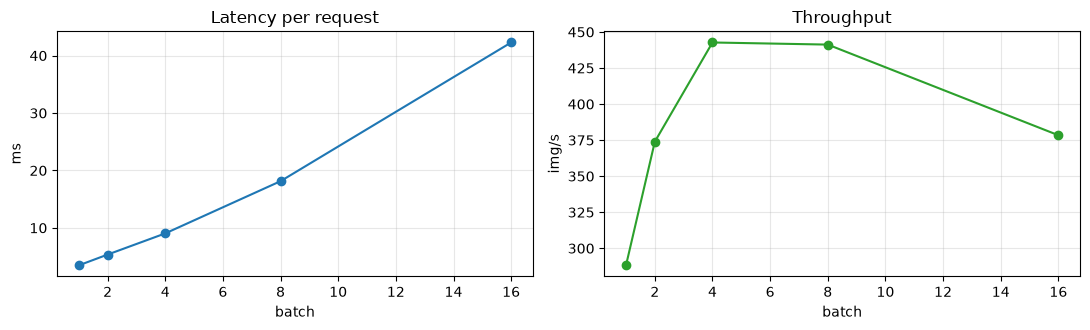

In [37]:
vit, _ = ZOO["ViT-Tiny"]
rows = []
with torch.inference_mode():
    for bs in [1, 2, 4, 8, 16]:
        xb = torch.randn(bs, 3, 224, 224)
        ms = bench(lambda: vit(xb), warmup=3, iters=10)
        with profile(activities=ACTIVITIES) as p:
            vit(xb)
        d = prof_df(p)
        rows.append({"batch": bs, "latency_ms": ms, "ms_per_image": ms / bs,
                     "img_per_s": bs / (ms / 1e3), "op_calls": int(d.calls.sum())})
sweep = pd.DataFrame(rows)
display(sweep.round(2))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(sweep.batch, sweep.latency_ms, "o-"); ax[0].set(xlabel="batch", ylabel="ms", title="Latency per request")
ax[1].plot(sweep.batch, sweep.img_per_s, "o-", color="tab:green"); ax[1].set(xlabel="batch", ylabel="img/s", title="Throughput")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

Note the `op_calls` column: **identical for every batch size.** The work per op grows, the
number of dispatches does not. That is the entire mechanism behind batching, visible in one
column.

### 2.8 Three optimisation experiments (and one trap)

We now run three standard CPU inference tweaks on ResNet-18, and use the profiler to explain
each result. **Run these yourself — the outcome is genuinely hardware-dependent, and that is
the lesson.**

In [38]:
r18, r18_x = ZOO["ResNet-18"]
default_threads = torch.get_num_threads()

# ---- experiment A: intra-op thread count ----
rows = []
for t in [1, 2, 4, default_threads * 2]:
    torch.set_num_threads(t)
    with torch.inference_mode():
        rows.append({"threads": t, "latency_ms": bench(lambda: r18(r18_x), warmup=3, iters=10)})
torch.set_num_threads(default_threads)
thr = pd.DataFrame(rows)
thr["speedup_vs_1"] = thr.latency_ms.iloc[0] / thr.latency_ms
display(thr.round(2))
print(f"(restored torch.set_num_threads({default_threads}))")

,threads,latency_ms,speedup_vs_1
0,1,53.89,1.00
1,2,46.70,1.15
2,4,35.44,1.52
3,8,32.60,1.65


(restored torch.set_num_threads(4))


Scaling is sublinear — convolutions do not parallelise perfectly, and on Apple Silicon the
efficiency cores contribute less than the performance cores. **Set this explicitly in
production**: the default is "all cores", which is wrong if you run several model replicas
on one machine, because they will fight each other.

In [39]:
# ---- experiment B: memory format ----
r18_cl = torchvision.models.resnet18(weights=None).eval().to(memory_format=torch.channels_last)
r18_cl.load_state_dict(r18.state_dict())
x_cl = r18_x.to(memory_format=torch.channels_last)

def breakdown(mdl, inp, label):
    with torch.inference_mode():
        mdl(inp)
        with profile(activities=ACTIVITIES) as p:
            mdl(inp)
        d = prof_df(p, top=4)
        d.insert(0, "run", label)
        d.insert(1, "wall_ms", round(bench(lambda: mdl(inp), warmup=3, iters=10), 2))
    return d

display(pd.concat([breakdown(r18, r18_x, "contiguous (NCHW)"),
                   breakdown(r18_cl, x_cl, "channels_last (NHWC)")],
                  ignore_index=True).round(3)[["run", "wall_ms", "name", "calls", "self_ms", "self_%"]])

USDT:2026-09-27 15:23:07 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:07 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:08 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:08 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,run,wall_ms,name,calls,self_ms,self_%
0,contiguous (NCHW),35.36,aten::_slow_conv2d_forward,20,26.262,78.479
1,contiguous (NCHW),35.36,aten::max_pool2d_with_indices,1,4.197,12.542
2,contiguous (NCHW),35.36,aten::native_batch_norm,20,1.537,4.593
3,contiguous (NCHW),35.36,aten::clamp_min_,17,0.764,2.284
4,channels_last (NHWC),27.70,aten::_slow_conv2d_forward,20,23.321,84.895
5,channels_last (NHWC),27.70,aten::native_batch_norm,20,2.102,7.650
6,channels_last (NHWC),27.70,aten::clamp_min_,17,0.741,2.699
7,channels_last (NHWC),27.70,aten::max_pool2d_with_indices,1,0.624,2.273


Compare the two runs **row by row**, not just the `wall_ms` totals. Two things can happen,
and the profiler distinguishes them:

* **The op name changes** — PyTorch selected a different kernel entirely
  (e.g. `mkldnn_convolution` instead of `_slow_conv2d_forward`). Big, obvious win.
* **The op name stays the same but its `self_ms` drops** — the same kernel ran faster
  because NHWC matches the memory order it wants, so it stops fighting the cache.

Watch `aten::max_pool2d_with_indices` in particular: pooling is very sensitive to layout and
often shows the largest relative change, even when convolution barely moves.

Whether the *net* result is a win depends on your CPU, your wheel and your tensor shapes —
**which is exactly why you profile instead of cargo-culting**.

In [40]:
# ---- experiment C: the bfloat16 trap ----
with torch.inference_mode():
    fp32_ms = bench(lambda: r18(r18_x), warmup=3, iters=10)
    with torch.autocast("cpu", dtype=torch.bfloat16):
        bf16_ms = bench(lambda: r18(r18_x), warmup=3, iters=5)

print(f"fp32           : {fp32_ms:7.1f} ms")
print(f"bfloat16 autocast: {bf16_ms:7.1f} ms   ->  {bf16_ms/fp32_ms:.1f}x the time")

def hot(label, ctx):
    with torch.inference_mode(), ctx:
        r18(r18_x)
        with profile(activities=ACTIVITIES) as p:
            r18(r18_x)
    d = prof_df(p, top=4); d.insert(0, "run", label); return d

display(pd.concat([hot("fp32", contextlib.nullcontext()),
                   hot("bf16", torch.autocast("cpu", dtype=torch.bfloat16))],
                  ignore_index=True).round(3)[["run", "name", "calls", "self_ms", "self_%"]])

fp32           :    35.2 ms
bfloat16 autocast:   681.0 ms   ->  19.3x the time


USDT:2026-09-27 15:23:14 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:14 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:15 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:23:15 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,run,name,calls,self_ms,self_%
0,fp32,aten::_slow_conv2d_forward,20,22.063,79.640
1,fp32,aten::max_pool2d_with_indices,1,3.284,11.854
2,fp32,aten::native_batch_norm,20,1.016,3.666
3,fp32,aten::clamp_min_,17,0.605,2.184
4,bf16,aten::_slow_conv2d_forward,20,698.343,99.031
5,bf16,aten::max_pool2d_with_indices,1,3.569,0.506
6,bf16,aten::copy_,28,1.064,0.151
7,bf16,aten::native_batch_norm,20,0.827,0.117


#### Read this table carefully — it is the most useful cell in Part 2

"Use lower precision, it is faster" is received wisdom from server CPUs with AVX-512-BF16
and from NVIDIA GPUs. On a machine without native bf16 kernels it can be **many times
slower**, and the profiler tells you *which* hypothesis is right:

* If the extra time appeared in **`aten::to` / `aten::_to_copy`** → the casts are the
  problem, and you could fix it by converting the weights once instead of per call.
* If the extra time appeared in **the convolution op itself** → there is no fast bf16
  kernel for this hardware and it fell back to a slow reference implementation. **No amount
  of cast-avoidance will help.** Abandon this optimisation.

On the reference Apple M3 it is emphatically the second case. Without the profiler you would
see only "bf16 is slow", form the wrong theory, and waste a day.

**The general lesson: an optimisation is a hypothesis. The profiler is the experiment.**

### 2.9 Inference memory footprint

Inference memory is small and boring compared to training — which is the point of measuring
it, because it sets the floor your serving process cannot go below.

In [41]:
rows = []
with torch.inference_mode():
    for name, (mdl, inp) in ZOO.items():
        mdl(inp)
        with profile(activities=ACTIVITIES, profile_memory=True) as p:
            mdl(inp)
        d = prof_df(p)
        rows.append({
            "model": name,
            "weights_MB": nparams(mdl) * 4 / 2**20,
            "alloc_MB":   d[d.self_mem_MB > 0].self_mem_MB.sum(),
            "freed_MB":  -d[d.self_mem_MB < 0].self_mem_MB.sum(),
        })
mem_df = pd.DataFrame(rows)
mem_df["net_MB"] = mem_df.alloc_MB - mem_df.freed_MB
display(mem_df.round(2))

USDT:2026-09-27 15:23:16 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:16 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:23:16 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:23:16 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:17 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:17 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,model,weights_MB,alloc_MB,freed_MB,net_MB
0,ResNet-18,44.59,309.18,309.18,0.0
1,MobileNetV3-Small,9.70,174.03,174.03,0.0
2,ViT-Tiny,10.90,68.61,68.61,0.0


Allocated ≈ freed: under `inference_mode` every intermediate dies as soon as it is consumed,
so peak memory is roughly *weights + the largest single activation*. Hold on to that number —
in Part 3.5 we measure the same models in training mode and the picture changes completely.

---
---
## Part 3 — Profiling **TRAINING**

Everything in Part 2 still applies, but a training step is a different animal:

| | Inference | Training |
|---|---|---|
| Passes | forward | forward **+ backward + optimiser** |
| Typical time split | 100% forward | ~1/3 forward, ~2/3 backward |
| Memory | weights + one activation | weights + **gradients + optimiser state + every saved activation** |
| Usual bottleneck | the model | often **the data pipeline**, not the model |
| Right metric | ms per request | **seconds per epoch / step** |
| Mode | `eval()` + `inference_mode()` | `train()` + grad enabled |

That last row matters: `torch.inference_mode()` here would be a bug, not an optimisation.

### 3.1 A properly labelled training step

Labelling is not optional in training. Without `record_function`, backward ops appear as a
flat list of `...Backward0` entries with no indication of which phase they belong to, and
you cannot answer the first question you will be asked: *"is it the forward, the backward,
or the optimiser?"*

In [42]:
torch.manual_seed(0)

train_model = torchvision.models.resnet18(weights=None)
train_model.fc = nn.Linear(512, 10)
train_model.train()                                    # <-- BatchNorm uses batch stats again

optimizer = torch.optim.AdamW(train_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

xb = torch.randn(8, 3, 224, 224)
yb = torch.randint(0, 10, (8,))


def train_step(model=train_model, opt=optimizer, x=xb, y=yb):
    with record_function("## train_step ##"):
        with record_function("01_zero_grad"):
            opt.zero_grad(set_to_none=True)
        with record_function("02_forward"):
            out = model(x)
        with record_function("03_loss"):
            loss = criterion(out, y)
        with record_function("04_backward"):
            loss.backward()
        with record_function("05_optimizer"):
            opt.step()
    return loss.item()


print(f"loss after one step: {train_step():.4f}")

loss after one step: 2.5725


USDT:2026-09-27 15:23:17 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,total_ms,share_%
0,## train_step ##,189.50,100.00
1,04_backward,111.49,58.83
6,02_forward,66.81,35.26
12,05_optimizer,10.93,5.77
42,01_zero_grad,0.15,0.08
53,03_loss,0.05,0.03


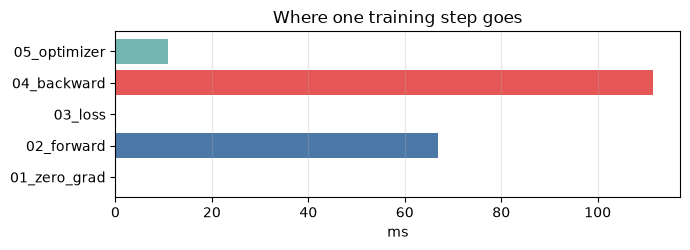

In [43]:
train_step()                                            # warmup (allocator + Adam state init)
with profile(activities=ACTIVITIES) as prof_train:
    train_step()

df = prof_df(prof_train, sort="cpu_time_total")
phases = df[df.name.str.match(r"\d\d_|## train_step")].copy()
total = phases.loc[phases.name.str.contains("train_step"), "total_ms"].iloc[0]
phases["share_%"] = 100 * phases.total_ms / total
display(phases.round(2)[["name", "total_ms", "share_%"]])

import matplotlib.pyplot as plt
bars = phases[~phases.name.str.contains("train_step")].sort_values("name")
plt.figure(figsize=(7, 2.6))
plt.barh(bars.name, bars.total_ms, color=["#999", "#4c78a8", "#999", "#e45756", "#72b7b2"])
plt.xlabel("ms"); plt.title("Where one training step goes"); plt.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

**Backward typically costs ~2× forward.** The intuition: for each forward op the autograd
engine must compute a gradient with respect to the *input* and one with respect to the
*weights* — roughly two matmuls where forward did one. If your measured ratio is far from
2:1, that itself is a finding worth chasing.

`zero_grad` is nearly free because we passed **`set_to_none=True`** (the default since torch
2.0). The alternative writes zeros into every gradient tensor — a full memory sweep over all
11.7 M parameters, every step, for nothing.

### 3.2 Backward ops are real ops

The autograd engine dispatches through the same machinery as forward, so the profiler sees
it. Backward kernels are named after the forward op that created them:
`ConvolutionBackward0`, `NativeBatchNormBackward0`, `ThresholdBackward0` (that is ReLU).

`autograd::engine::evaluate_function: ...` rows are the engine's own bookkeeping around each
node.

In [44]:
d = prof_df(prof_train)
bwd = d[d.name.str.contains("Backward|autograd::engine", case=False)]
fwd = d[~d.name.str.contains("Backward|autograd::engine|^\\d\\d_|## ", case=False, regex=True)]

print(f"backward-attributed self time: {bwd.self_ms.sum():7.1f} ms  ({len(bwd)} distinct ops)")
print(f"other (fwd + optim) self time: {fwd.self_ms.sum():7.1f} ms  ({len(fwd)} distinct ops)")
print("\nheaviest backward nodes:")
display(bwd.head(6).round(3)[["name", "calls", "self_ms", "self_%"]])

backward-attributed self time:   108.0 ms  (31 distinct ops)
other (fwd + optim) self time:    80.7 ms  (59 distinct ops)

heaviest backward nodes:


,name,calls,self_ms,self_%
0,aten::_slow_conv2d_backward,20,97.181,51.284
4,aten::native_batch_norm_backward,20,4.792,2.529
6,aten::threshold_backward,17,2.691,1.420
12,04_backward,1,1.240,0.654
16,MaxPool2DWithIndicesBackward0,1,0.843,0.445
18,aten::max_pool2d_with_indices_backward,1,0.753,0.397


### 3.3 Memory: the real difference between training and inference

Forward under `inference_mode` frees each intermediate immediately. **Autograd cannot** — it
must keep every tensor that a backward formula will need. That is what "activation memory"
means, and it is why batch size is limited by memory rather than by compute.

Let us measure the same model, same batch, in both modes.

In [45]:
def peak_alloc(fn, label):
    with profile(activities=ACTIVITIES, profile_memory=True) as p:
        fn()
    d = prof_df(p)
    return {"mode": label,
            "allocated_MB": d[d.self_mem_MB > 0].self_mem_MB.sum(),
            "freed_MB":    -d[d.self_mem_MB < 0].self_mem_MB.sum(),
            "op_calls":     int(d.calls.sum())}

eval_model = torchvision.models.resnet18(weights=None)
eval_model.fc = nn.Linear(512, 10); eval_model.eval()

# IMPORTANT: we keep the output alive in `held`. If we let it go out of scope, Python frees
# the whole graph *inside* the profiled region and the retained memory looks like zero.
held = []

with torch.inference_mode():
    eval_model(xb)
    r_inf = peak_alloc(lambda: held.append(eval_model(xb)), "eval + inference_mode")

train_step()
r_fwd = peak_alloc(lambda: held.append(train_model(xb)), "train, forward only (graph kept)")
r_all = peak_alloc(train_step, "train, full step")

mem = pd.DataFrame([r_inf, r_fwd, r_all])
mem["net_retained_MB"] = mem.allocated_MB - mem.freed_MB
display(mem.round(1))

held.clear()   # release the graphs we deliberately pinned

USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
[W927 15:23:18.701774000 CPUAllocator.cpp:245] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event


USDT:2026-09-27 15:23:18 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,mode,allocated_MB,freed_MB,op_calls,net_retained_MB
0,eval + inference_mode,618.3,618.3,507,0.0
1,"train, forward only (graph kept)",618.4,453.7,568,164.7
2,"train, full step",1503.9,1461.3,3356,42.7


Ignore the `allocated_MB` column for a moment and read **`net_retained_MB`**:

* **Row 1 (`inference_mode`)** — allocated ≈ freed, retained ≈ **0 MB**. Every intermediate
  died the instant it was consumed. Peak memory is just weights + the largest single
  activation.
* **Row 2 (same forward, grad enabled)** — allocated is nearly identical, but a large chunk
  is **never freed**. Those retained megabytes are the saved activations, pinned in memory
  waiting for `loss.backward()` to consume them.
* **Row 3 (full step)** — the backward pass finally releases them, which is why retention
  drops again, and total traffic roughly doubles.

The cost of training is not that it allocates more. It is that it **cannot let go**.

This is the mechanism behind two standard techniques you will meet later:
**gradient checkpointing** (recompute activations instead of storing them — trade compute
for memory) and **gradient accumulation** (run several small batches before stepping —
trade steps for memory).

#### A note on `export_memory_timeline()`

The profiler can emit an interactive memory-over-time plot. It is **deprecated as of torch
2.14** in favour of `torch.cuda.memory._record_memory_history()` /
`_export_memory_snapshot()` — but that replacement is CUDA-only, so on CPU the deprecated
call is still the only built-in option. Included with the warning suppressed:

USDT:2026-09-27 15:23:19 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:23:19 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


wrote profiler_out/train_memory_timeline.html  (95 KB) - open it in a browser


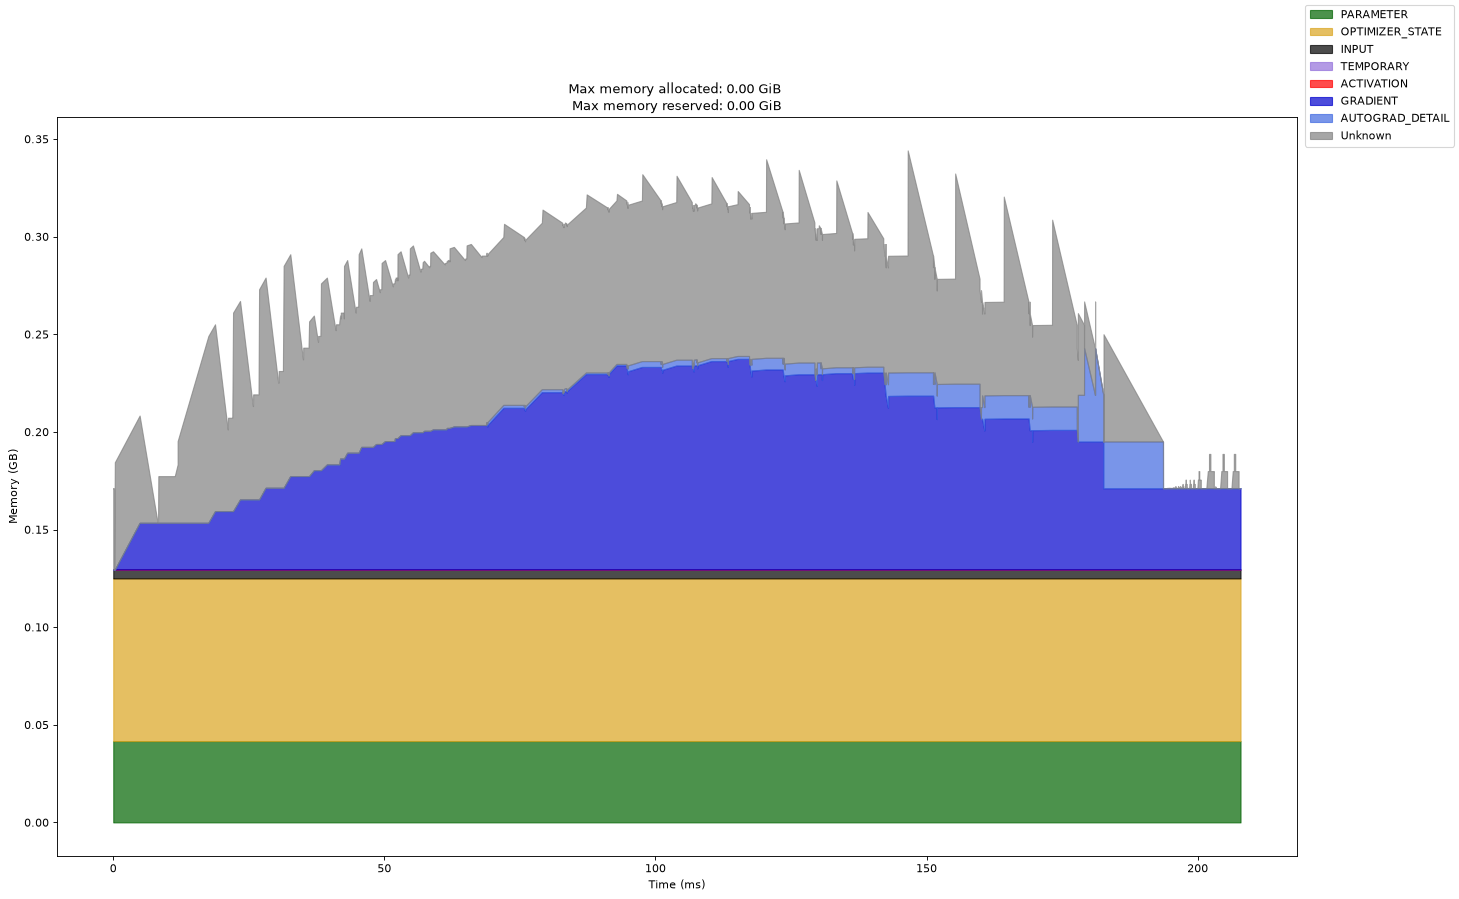

In [46]:
import warnings
mem_html = OUT / "train_memory_timeline.html"
try:
    with profile(activities=ACTIVITIES, profile_memory=True, with_stack=True,
                 record_shapes=True, experimental_config=VERBOSE_CFG) as p_mem:
        train_step()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        p_mem.export_memory_timeline(str(mem_html), device="cpu")
    print(f"wrote {mem_html}  ({mem_html.stat().st_size/1e3:.0f} KB) - open it in a browser")
except Exception as e:
    print(f"not available in this build: {type(e).__name__}: {e}")

### 3.4 The most common real finding: **the model is not the bottleneck**

In production training jobs the single most frequent profiler finding is that the GPU/CPU
sits idle waiting for data. Augmentation, decoding and disk I/O run in Python; if they are
not overlapped with compute, your expensive accelerator spends its life blocked.

We simulate it with a dataset whose `__getitem__` burns CPU (a stand-in for JPEG decode +
augmentation), then profile the loop with data fetching and compute **separately labelled**.

> The dataset lives in its own `.py` file because DataLoader workers are spawned as fresh
> processes on macOS and Windows, and must be able to *import* the class. A class defined in
> a notebook cell cannot be pickled to a worker. This is a real-world constraint, not a
> notebook quirk.

In [47]:
%%writefile slow_data.py
"""Stand-in for a CPU-heavy data pipeline (decode + augment)."""
import time
import torch
from torch.utils.data import Dataset


class SlowDataset(Dataset):
    def __init__(self, n=64, size=64, delay=0.004):
        self.n, self.size, self.delay = n, size, delay

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        t0 = time.perf_counter()
        while time.perf_counter() - t0 < self.delay:    # busy-wait == CPU-bound transform
            pass
        g = torch.Generator().manual_seed(i)
        x = torch.randn(3, self.size, self.size, generator=g)
        y = torch.randint(0, 10, (1,), generator=g).item()
        return x, y

Writing slow_data.py


In [48]:
import importlib, slow_data
importlib.reload(slow_data)
from torch.utils.data import DataLoader

small = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
                      nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(16, 10)).train()
small_opt = torch.optim.SGD(small.parameters(), lr=0.01)


def run_epoch(loader):
    it = iter(loader)
    while True:
        with record_function("DATA_WAIT"):                # time blocked on the loader
            batch = next(it, None)
        if batch is None:
            break
        xb_, yb_ = batch
        with record_function("COMPUTE"):                  # time doing actual training
            small_opt.zero_grad(set_to_none=True)
            criterion(small(xb_), yb_).backward()
            small_opt.step()


def data_vs_compute(loader, label):
    run_epoch(loader)                                     # warmup (also starts workers)
    # No schedule here: the epoch is short, so we profile all of it and keep every event.
    with profile(activities=ACTIVITIES) as p:
        run_epoch(loader)
    d = prof_df(p, sort="cpu_time_total")
    out = d[d.name.isin(["DATA_WAIT", "COMPUTE"])].copy()
    out["share_%"] = 100 * out.total_ms / out.total_ms.sum()
    out.insert(0, "run", label)
    return out[["run", "name", "calls", "total_ms", "share_%"]]


ds = slow_data.SlowDataset()
dl_naive = DataLoader(ds, batch_size=8, num_workers=0)

split = data_vs_compute(dl_naive, "num_workers=0")
display(split.round(2))

USDT:2026-09-27 15:23:20 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:23:20 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,run,name,calls,total_ms,share_%
0,num_workers=0,DATA_WAIT,9,263.14,97.18
2,num_workers=0,COMPUTE,8,7.63,2.82


`DATA_WAIT` dominating `COMPUTE` is the signature of an **input-bound** training job.

The fix is not to make the model faster — that would make the ratio *worse*. The fix is to
**overlap** loading with compute using worker processes.

* `num_workers=k` — k subprocesses build batches ahead of time.
* `persistent_workers=True` — do not tear them down between epochs (worker startup is
  expensive; without this, short epochs pay it every time).
* `prefetch_factor` — batches queued per worker.
* `pin_memory=True` — only useful for CUDA transfers; no effect on a CPU-only run.

In [49]:
def epoch_time(loader, reps=2):
    run_epoch(loader)                                       # warm the workers
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); run_epoch(loader); ts.append((time.perf_counter() - t0) * 1e3)
    return min(ts)


rows = [{"config": "num_workers=0 (naive)", "epoch_ms": epoch_time(dl_naive)}]
loaders = {}
for nw in [2, 4]:
    dl = DataLoader(ds, batch_size=8, num_workers=nw,
                    persistent_workers=True, prefetch_factor=2)
    loaders[nw] = dl
    rows.append({"config": f"num_workers={nw}, persistent, prefetch=2", "epoch_ms": epoch_time(dl)})

res = pd.DataFrame(rows)
res["speedup"] = res.epoch_ms.iloc[0] / res.epoch_ms
display(res.round(2))

,config,epoch_ms,speedup
0,num_workers=0 (naive),269.36,1.00
1,"num_workers=2, persistent, prefetch=2",133.94,2.01
2,"num_workers=4, persistent, prefetch=2",70.88,3.80


In [50]:
# re-profile the fixed loop: DATA_WAIT should have collapsed
fixed = data_vs_compute(loaders[4], "num_workers=4")
display(pd.concat([split, fixed], ignore_index=True).round(2))

for dl in list(loaders.values()):
    del dl
loaders.clear()

USDT:2026-09-27 15:23:23 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:23 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,run,name,calls,total_ms,share_%
0,num_workers=0,DATA_WAIT,9,263.14,97.18
1,num_workers=0,COMPUTE,8,7.63,2.82
2,num_workers=4,DATA_WAIT,9,60.73,86.97
3,num_workers=4,COMPUTE,8,9.10,13.03


`DATA_WAIT` drops by several times in absolute milliseconds, because loading now happens
*while* the main process computes. **The work did not get cheaper — it got overlapped.**
The profiler is what distinguishes those two, and it is a distinction wall-clock time alone
cannot make.

Note that `DATA_WAIT` probably still holds the larger *share*. That is not a failure of the
fix — it is a statement about this toy model, which computes so little that no amount of
overlapping can hide a deliberately slow dataset. Two readings follow, and both are useful:

* **The ratio `COMPUTE / (COMPUTE + DATA_WAIT)` is your pipeline efficiency.** It should have
  risen sharply. That is the number to track.
* **If it is still low after adding workers, the dataset itself is too slow.** Now you go and
  fix `__getitem__`: cache decoded tensors, move augmentation onto the GPU, or switch to a
  pre-shuffled binary format. The profiler has told you where to aim, which is the whole job.

### 3.5 Comparing architectures by training cost

Inference latency is not proportional to training cost: the backward pass of an op is not
always 2× its forward, and some architectures have far more backward nodes than forward ops.

In [51]:
torch.manual_seed(0)
TRAIN_ZOO = {
    "ResNet-18":         (torchvision.models.resnet18(num_classes=10, weights=None), torch.randn(4, 3, 224, 224)),
    "MobileNetV3-Small": (torchvision.models.mobilenet_v3_small(num_classes=10, weights=None), torch.randn(4, 3, 224, 224)),
    "ViT-Tiny (fused attn)": (TinyViT(),                                             torch.randn(4, 3, 224, 224)),
    "ViT-Tiny (naive attn)": (TinyViT(fused_attn=False),                             torch.randn(4, 3, 224, 224)),
}

rows = []
for name, (mdl, inp) in TRAIN_ZOO.items():
    mdl.train()
    opt = torch.optim.SGD(mdl.parameters(), lr=0.01)
    tgt = torch.randint(0, 10, (inp.size(0),))

    def step(mdl=mdl, opt=opt, inp=inp, tgt=tgt):
        opt.zero_grad(set_to_none=True)
        with record_function("fwd"):
            out = mdl(inp)
        loss = criterion(out, tgt)
        with record_function("bwd"):
            loss.backward()
        opt.step()

    step()
    with profile(activities=ACTIVITIES, profile_memory=True) as p:
        step()
    d = prof_df(p, sort="cpu_time_total")
    get = lambda k: float(d.loc[d.name == k, "total_ms"].iloc[0]) if (d.name == k).any() else float("nan")
    f, b = get("fwd"), get("bwd")
    rows.append({"model": name, "params_M": nparams(mdl) / 1e6,
                 "step_ms": bench(step, warmup=2, iters=8),
                 "fwd_ms": f, "bwd_ms": b, "bwd/fwd": b / f,
                 "op_calls": int(d.calls.sum()),
                 "alloc_MB": d[d.self_mem_MB > 0].self_mem_MB.sum()})

train_df = pd.DataFrame(rows)
display(train_df.round(2))

USDT:2026-09-27 15:23:54 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:23:54 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:23:55 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:23:55 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:24:00 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:24:00 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-27 15:24:00 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:24:00 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,model,params_M,step_ms,fwd_ms,bwd_ms,bwd/fwd,op_calls,alloc_MB
0,ResNet-18,11.18,87.09,32.21,53.65,1.67,1490,730.69
1,MobileNetV3-Small,1.53,149.73,75.50,97.76,1.29,118993,451.81
2,ViT-Tiny (fused attn),2.86,23.30,8.19,15.03,1.84,2653,182.88
3,ViT-Tiny (naive attn),2.86,25.40,10.47,15.71,1.50,6721,260.25


Two things to read here.

**First, the `bwd/fwd` column.** The textbook figure is ~2×; conv and GEMM-heavy models
usually land somewhere below it. Look at `op_calls` alongside it: MobileNetV3-Small is far
ahead of the others, for the reason §2.4 identified — and in training it pays the dispatch
cost **twice**, once going forward and once coming back. An architecture that is
overhead-bound in inference is overhead-bound in training as well.

**Second — and this is the important one — compare the two ViT rows.**

The fused kernel won inference by ~1.2× in §2.6. In *training* the gain is smaller, and the
`fwd_ms` / `bwd_ms` columns show why: fusion speeds up the forward pass, but the backward
pass costs about the same either way. Now look at `alloc_MB` — that is where the fused
kernel wins clearly.

The hand-written version builds the `197 × 197` score matrix and its softmax for every head
in every block, and under autograd those are **saved activations** that must survive until
backward. The fused kernel does not keep them. In training the same change is as much a
*memory* optimisation as a speed one.

> ### The lesson
> **An optimisation's payoff depends on the mode.** The same change can buy speed in
> inference and mostly memory in training. Profile the mode you actually ship.

### 3.6 The production recipe

Everything above, assembled into the pattern you should copy into a real training script.

In [52]:
def profile_training(model, loader_or_batches, optimizer, criterion, out_dir,
                     skip_first=2, wait=1, warmup=1, active=3, repeat=1):
    """Profile a window of steps from a real training loop and write a Perfetto trace."""
    model.train()
    prof_sched = schedule(skip_first=skip_first, wait=wait, warmup=warmup,
                          active=active, repeat=repeat)
    n_steps = skip_first + repeat * (wait + warmup + active)

    with profile(
        activities=ACTIVITIES,
        schedule=prof_sched,
        on_trace_ready=tensorboard_trace_handler(str(out_dir)),
        record_shapes=True,        # per-shape breakdown
        profile_memory=True,       # activation memory
        with_stack=True,           # source attribution + nn.Module spans
        with_flops=True,           # arithmetic intensity
        experimental_config=VERBOSE_CFG,   # <-- required for with_stack (see 1.6)
        acc_events=True,           # keep stats across cycles
    ) as prof:
        for i, (x, y) in zip(range(n_steps), loader_or_batches):
            with record_function("## step ##"):
                optimizer.zero_grad(set_to_none=True)
                with record_function("forward"):
                    out = model(x)
                loss = criterion(out, y)
                with record_function("backward"):
                    loss.backward()
                with record_function("optimizer"):
                    optimizer.step()
            prof.step()                      # <-- never forget this
    return prof


batches = [(torch.randn(8, 3, 64, 64), torch.randint(0, 10, (8,))) for _ in range(20)]
demo_net = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                         nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, 10))
demo_opt = torch.optim.AdamW(demo_net.parameters(), lr=1e-3)

pt = profile_training(demo_net, batches, demo_opt, criterion, OUT / "train_traces")

print("traces written:")
for f in sorted((OUT / "train_traces").glob("*")):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.2f} MB)")
print()
display(prof_df(pt, top=6).round(3)[["name", "calls", "self_ms", "self_%", "self_mem_MB"]])

traces written:
  phix-m3.local_79272.1790497441246233000.pt.trace.json  (5.67 MB)



USDT:2026-09-27 15:24:01 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:24:01 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls,self_ms,self_%,self_mem_MB
0,aten::native_batch_norm,3,1.446,27.255,-0.001
1,aten::_slow_conv2d_backward,3,0.663,12.491,-10.125
2,aten::native_batch_norm_backward,3,0.477,8.985,-12.000
3,aten::_slow_conv2d_forward,3,0.447,8.427,-10.125
4,aten::div,21,0.316,5.953,12.015
5,aten::threshold_backward,3,0.305,5.750,12.000


Turn `with_stack` and `profile_memory` **off** once you have found your bottleneck — they
are diagnostic tools, not monitoring. Leaving them on in a long job wastes real time and
produces enormous traces.

---
---
## Part 4 — Reading traces, and the caveats

### 4.1 The timeline in Perfetto

Everything so far was *aggregate*. Aggregates hide gaps. A trace does not.

1. Go to **<https://ui.perfetto.dev>** (runs locally in your browser; nothing is uploaded).
2. Drag in any `.json` from `profiler_out/`.
3. Navigate: **W/S** zoom, **A/D** pan, **M** mark a selection, click an op for details,
   drag a region for aggregate statistics over it.

What to look for, in order:

| Observation | Diagnosis |
|---|---|
| Your `## label ##` spans are long but contain few, wide op blocks | Compute-bound. Optimise the algorithm or the kernel. |
| Spans contain thousands of hair-thin slivers | **Overhead-bound.** Fuse, batch, or `torch.compile`. (§2.4) |
| Visible **gaps** between steps | Something outside PyTorch: data loading, logging, sync. (§3.4) |
| One thread busy, others idle | Thread count or a non-parallelised op. (§2.8 A) |
| A long block right before each step | Data wait. (§3.4) |

Let us write a trace containing several labelled steps, which is what you actually want to
stare at.

In [53]:
multi = OUT / "multi_step_trace.json"
train_step()
with profile(activities=ACTIVITIES, record_shapes=True) as p_multi:
    for i in range(3):
        with record_function(f"## epoch0_step{i} ##"):
            train_step()
p_multi.export_chrome_trace(str(multi))
print(f"{multi}  ({multi.stat().st_size/1e6:.2f} MB)")
print("\n-> open https://ui.perfetto.dev and drag this file in.")
print("   Find the three '## epoch0_step*' spans and compare their widths.")
print("   Zoom into one: forward ops, then the Backward0 nodes, then AdamW.")

USDT:2026-09-27 15:24:01 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


profiler_out/multi_step_trace.json  (4.41 MB)

-> open https://ui.perfetto.dev and drag this file in.
   Find the three '## epoch0_step*' spans and compare their widths.
   Zoom into one: forward ops, then the Backward0 nodes, then AdamW.


USDT:2026-09-27 15:24:02 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


### 4.2 Flame graphs from `export_stacks()`

`export_stacks()` writes **folded stacks**: one line per call path, ending in a count.
That is the input format for Brendan Gregg's FlameGraph tools.

```bash
git clone https://github.com/brendangregg/FlameGraph
./FlameGraph/flamegraph.pl \
    --title "ResNet-18 forward (self CPU time)" \
    --countname "us" \
    profiler_out/resnet18_stacks.txt > resnet18_flame.svg
open resnet18_flame.svg
```

Width = time. The widest plateau at the bottom of a tower is your hotspot.

In [54]:
print(f"--- first lines of {stacks_file.name} ---")
lines = stacks_file.read_text().splitlines()
for ln in lines[:3]:
    path, _, count = ln.rpartition(" ")
    print(f"  {count:>8} us   {path[:110]}")
print(f"  ... {len(lines):,} folded stacks total")

--- first lines of resnet18_stacks.txt ---
         1 us   threading.py(1015):__bootstrap
         2 us   threading.py(1015):__bootstrap;threading.py(1044):__bootstrap_inner
         1 us   threading.py(1015):__bootstrap;threading.py(1044):__bootstrap_inner;ipykernel/parentpoller.py(62):_run;threadi
  ... 330 folded stacks total


### 4.3 Caveats — how to not fool yourself

1. **The profiler is not free.** Instrumentation costs ~1–3 µs per op. For an
   overhead-bound model like MobileNetV3-Small that can be a *large* fraction of runtime.
   **Always confirm a speedup with a plain timer, never with profiler totals.**
2. **Self times sum to runtime; total times do not.** (§1.2)
3. **Iteration 0 is a lie.** Use `warmup` in `schedule`, or discard it manually. (§2.1)
4. **The first `profile()` context itself has a startup cost.** Discard the first profiled
   window too — that is what `warmup` is for.
5. **Thread count changes every number.** Record `torch.get_num_threads()` alongside results,
   and compare only runs that used the same value.
6. **Op names are build-dependent.** `_slow_conv2d_forward` vs `mkldnn_convolution` vs
   `thnn_conv2d` depends on your wheel, your CPU and the tensor layout. Compare *your*
   before and after, not your names against a tutorial's.
7. **Aggregates hide bimodality.** An op averaging 5 ms might be 1 ms nine times and 41 ms
   once. Only the timeline shows that.
8. **On accelerators, CPU time ≠ device time.** Launches are asynchronous, so a CPU-side
   measurement records queueing, not execution. On CUDA you add `ProfilerActivity.CUDA`;
   on MPS, see below.

### 4.4 Profiling on Apple Silicon GPU (MPS)

There is **no `ProfilerActivity.MPS`**. With `activities=[ProfilerActivity.CPU]` and tensors
on `mps`, what you measure is the **CPU cost of encoding work to the GPU**, not the GPU's
execution time — and because dispatch is asynchronous those numbers are close to meaningless
unless you synchronise.

Rules for MPS:

* Call `torch.mps.synchronize()` after warmup **and** at the end of the profiled region,
  inside the profiler scope, so pending work is attributed.
* Treat the result as "how much CPU do I burn driving the GPU", which is still a legitimate
  question — it tells you whether you are launch-bound.
* For actual GPU kernel timings, use `torch.mps.profiler.profile(...)` with Xcode's
  **Instruments / Metal System Trace**, or `torch.mps.profiler.metal_capture()`.

In [55]:
if torch.backends.mps.is_available():
    mps_model = torchvision.models.resnet18(weights=None).eval().to("mps")
    mps_x = torch.randn(4, 3, 224, 224, device="mps")

    with torch.inference_mode():
        for _ in range(3):
            mps_model(mps_x)
        torch.mps.synchronize()                         # finish warmup before timing

        t0 = time.perf_counter()
        for _ in range(10):
            mps_model(mps_x)
        torch.mps.synchronize()                         # <-- without this the number is fiction
        mps_ms = (time.perf_counter() - t0) / 10 * 1e3

        with profile(activities=ACTIVITIES) as p_mps:
            with record_function("## mps_forward ##"):
                mps_model(mps_x)
                torch.mps.synchronize()                 # inside the scope

    cpu_ms = bench(lambda: ZOO["ResNet-18"][0](ZOO["ResNet-18"][1]), warmup=3, iters=10)
    print(f"ResNet-18 batch 4 -- CPU: {cpu_ms:.1f} ms | MPS: {mps_ms:.1f} ms "
          f"({cpu_ms/mps_ms:.2f}x)")
    print("\nCPU-side view of driving the GPU (encode cost, not kernel time):")
    display(prof_df(p_mps, top=6).round(3)[["name", "calls", "self_ms", "avg_self_us"]])
    print("\ntorch.mps.profiler API:",
          [a for a in dir(torch.mps.profiler) if not a.startswith("_")])
else:
    print("MPS not available on this machine - skipping.")

USDT:2026-09-27 15:24:02 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:24:02 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


ResNet-18 batch 4 -- CPU: 28.5 ms | MPS: 11.1 ms (2.57x)

CPU-side view of driving the GPU (encode cost, not kernel time):


,name,calls,self_ms,avg_self_us
0,## mps_forward ##,1,9.887,9886.570
1,aten::native_batch_norm,20,1.015,50.732
2,aten::_mps_convolution,20,0.618,30.899
3,aten::linear,1,0.047,47.203
4,aten::empty,102,0.033,0.319
5,aten::relu_,17,0.030,1.760



torch.mps.profiler API: ['Iterator', 'Literal', 'ProfilerMode', 'contextlib', 'is_capturing_metal', 'is_metal_capture_enabled', 'metal_capture', 'profile', 'start', 'stop', 'torch']


Notice the op names change to `aten::_mps_convolution` and friends: the profiler is showing
you **which backend was selected**, which is useful in its own right. If you ever see
`aten::` CPU ops in what should be an MPS run, you have found a silent fallback — an
operator MPS does not implement, quietly copying your tensors to the CPU and back. That is
one of the most valuable things the profiler catches on Apple Silicon.

---
---
## Part 5 — Trace analysis: Perfetto, HTA, and doing it yourself

Parts 1–3 read the profiler's **aggregate table**. A trace file holds much more: every
event, in time order, with its thread, its nesting and its shapes. This part covers three
ways to get at that, from simplest to heaviest.

| Path | Needs | Good for |
|---|---|---|
| **Perfetto / `chrome://tracing`** | a browser | Looking. Gaps, stalls, ordering. |
| **Parse the JSON yourself** | `json` + `pandas` | Scripted checks, CI, custom metrics |
| **Holistic Trace Analysis (HTA)** | `pip install HolisticTraceAnalysis` | Multi-rank GPU jobs, trace diffing |

### 5.1 Capturing a trace that HTA can actually read

> ### ⚠️ The gotcha that costs an afternoon
> HTA needs **`ProfilerStep#N` markers** to segment a trace into iterations. Those markers
> are only written when you profile with a `schedule` **and** hand the file to
> **`tensorboard_trace_handler`**.
>
> A manual `prof.export_chrome_trace(...)` — even from a scheduled profiler — does **not**
> contain them, and HTA dies with a confusing
> `AttributeError: Can only use .str accessor with string values`. That error is HTA
> failing to find any ProfilerStep symbols, not a problem with your pandas install.

`ws_trace.capture_trace()` in this folder does it correctly. Note it gives **each trace its
own directory**, because `TraceAnalysis(trace_dir=...)` loads *every* file in a directory
and treats each one as a separate distributed rank.

In [56]:
sys.path.insert(0, str(Path.cwd()))
import ws_trace
from ws_trace import (capture_trace, chrome_trace_ops, hta_available,
                      quiet_hta, HTA_ON_CPU)

TRACES = OUT / "traces"

# a training step to profile
trace_model = torchvision.models.resnet18(num_classes=10, weights=None)
trace_model.train()
trace_opt = torch.optim.SGD(trace_model.parameters(), lr=0.01)
tx, ty = torch.randn(4, 3, 224, 224), torch.randint(0, 10, (4,))


def traced_step():
    trace_opt.zero_grad(set_to_none=True)
    with record_function("## train_step ##"):
        loss = nn.CrossEntropyLoss()(trace_model(tx), ty)
        loss.backward()
        trace_opt.step()


base_dir, base_file = capture_trace(traced_step, TRACES, "baseline", warmup=1, active=3)
print(f"trace dir : {base_dir}")
print(f"trace file: {base_file.name}  ({base_file.stat().st_size/1e6:.2f} MB)")
print(f"ProfilerStep markers present: {'ProfilerStep' in base_file.read_text()[:2_000_000]}")

USDT:2026-09-27 15:24:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


trace dir : profiler_out/traces/baseline
trace file: phix-m3.local_79272.1790497443615848000.pt.trace.json  (1.78 MB)
ProfilerStep markers present: True


USDT:2026-09-27 15:24:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:24:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:24:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


### 5.2 The simple path — parse the Chrome Trace yourself

Before reaching for a library, know that a Chrome Trace is **just JSON**: a list of events
with `name`, `ts`, `dur`, `cat`, `pid`, `tid`. Anything the profiler's table shows you, you
can recompute from that file with `pandas` alone — which means you can put it in CI without
adding a dependency.

The one subtlety is the one from §1.2: **trace durations are inclusive**, so summing them
double-counts nesting. `ws_trace.chrome_trace_ops()` recovers self time the same way the
profiler does — sweep each thread's events in time order, keep a stack of open parents, and
subtract each child's duration from its parent.

In [57]:
ops = chrome_trace_ops(base_file, top=8)
display(ops.round(2))
print(f"(3 profiled steps, so divide `calls` and `self_ms` by 3 for a per-step figure)")

,name,calls,self_ms,total_ms,self_%
0,aten::_slow_conv2d_backward,60,156.07,161.07,51.30
1,aten::_slow_conv2d_forward,60,78.50,78.67,25.80
2,aten::native_batch_norm,60,23.34,23.53,7.67
3,aten::max_pool2d_with_indices,3,13.46,13.46,4.43
4,aten::add_,294,8.37,8.37,2.75
5,aten::native_batch_norm_backward,60,7.32,7.49,2.41
6,aten::fill_,123,5.21,5.21,1.71
7,aten::threshold_backward,51,4.61,4.61,1.52


(3 profiled steps, so divide `calls` and `self_ms` by 3 for a per-step figure)


In [58]:
# sanity check: does our hand-rolled parser agree with the profiler's own table?
traced_step()
with profile(activities=ACTIVITIES) as p_check:
    traced_step()
ref = prof_df(p_check, top=5)[["name", "calls", "self_ms"]].copy()
ref.columns = ["name", "calls_1step", "self_ms_1step"]

mine = ops.head(5)[["name", "calls", "self_ms"]].copy()
mine["calls"] //= 3
mine["self_ms"] /= 3
mine.columns = ["name", "calls_from_trace", "self_ms_from_trace"]

display(ref.merge(mine, on="name", how="outer").round(2))

USDT:2026-09-27 15:24:03 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:24:03 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


,name,calls_1step,self_ms_1step,calls_from_trace,self_ms_from_trace
0,aten::_slow_conv2d_backward,20,55.54,20,52.02
1,aten::_slow_conv2d_forward,20,29.76,20,26.17
2,aten::add_,98,3.14,98,2.79
3,aten::max_pool2d_with_indices,1,4.28,1,4.49
4,aten::native_batch_norm,20,7.84,20,7.78


The two columns should agree to within run-to-run noise. **That is the point of the
exercise**: the trace file contains everything the table does, so you are never locked into
one viewer.

#### And the viewer

The same file opens directly in a browser. Nothing is uploaded — both viewers run locally.

In [59]:
print("Open either of these and drag in the file below:")
print("   https://ui.perfetto.dev        (current)")
print("   chrome://tracing               (legacy, Chromium/Chrome)")
print()
for f in sorted(TRACES.rglob("*.pt.trace.json")):
    print(f"   {f}")
print()
print("Once open:  W/S zoom · A/D pan · click an op for details · drag to select a range")
print("Look for:   the '## train_step ##' spans, then the ...Backward0 nodes inside them")

Open either of these and drag in the file below:
   https://ui.perfetto.dev        (current)
   chrome://tracing               (legacy, Chromium/Chrome)

   profiler_out/traces/baseline/phix-m3.local_79272.1790497443615848000.pt.trace.json

Once open:  W/S zoom · A/D pan · click an op for details · drag to select a range
Look for:   the '## train_step ##' spans, then the ...Backward0 nodes inside them


### 5.3 Holistic Trace Analysis

[HTA](https://github.com/facebookresearch/HolisticTraceAnalysis) is Meta's trace analysis
library, built for the problem of **large distributed GPU training jobs**: dozens of ranks,
each producing a trace, and a question like "which rank is the straggler, and is it blocked
on communication or on compute?"

```bash
pip install HolisticTraceAnalysis
```

Point `TraceAnalysis` at a directory of traces and it parses them into DataFrames.

> **Silencing it.** HTA prints a line per file it touches (`Parsed ... / leaving
> parse_traces ...`). It logs those through a logger named `hta` at **WARNING** level, so
> the reflexive `logging.disable(logging.INFO)` does nothing whatsoever. You have to raise
> that logger's level: `logging.getLogger("hta").setLevel(logging.ERROR)`, which is all
> `ws_trace.quiet_hta()` does.

In [60]:
if not hta_available():
    print("HolisticTraceAnalysis not installed - run: pip install HolisticTraceAnalysis")
else:
    quiet_hta()        # see note below - `logging.disable(logging.INFO)` does NOT work

    from hta.trace_analysis import TraceAnalysis

    analyzer = TraceAnalysis(trace_dir=str(base_dir))
    print("profiler steps found:", analyzer.get_profiler_steps())

profiler steps found: [np.int64(1), np.int64(2)]


#### The normalised event table

`t.get_trace(rank)` returns every event as a DataFrame row. Note that `name` and `cat` are
**integer symbol IDs**, not strings — HTA interns them so a multi-gigabyte multi-rank trace
still fits in memory. Decode them through the symbol table.

In [61]:
if hta_available():
    ev = analyzer.t.get_trace(0)
    print(f"events: {ev.shape[0]:,} rows x {ev.shape[1]} columns")
    print("columns:", list(ev.columns))

    symbols = analyzer.t.symbol_table.get_sym_table()      # id -> name
    ev = ev.copy()
    ev["op"] = ev["name"].map(lambda i: symbols[i])
    ev["category"] = ev["cat"].map(lambda i: symbols[i])

    display(ev[["op", "category", "ts", "dur", "tid", "iteration"]].head(5))
    print("\nevent categories:", ev.category.value_counts().to_dict())

events: 2,980 rows x 20 columns
columns: ['index', 'name', 'ts', 'pid', 'tid', 'cat', 'dur', 'end', 'stream', 'correlation', 'bytes', 'memory_bw_gbps', 'wait_on_stream', 'wait_on_cuda_event_record_corr_id', 'input_dims', 'input_type', 'input_strides', 'external_id', 'index_correlation', 'iteration']


,op,category,ts,dur,tid,iteration
8,ProfilerStep#1,user_annotation,0,106989.0,2159634,1
9,Optimizer.zero_grad#SGD.zero_grad,user_annotation,42,153.0,2159634,1
10,## train_step ##,user_annotation,201,106763.0,2159634,1
11,aten::conv2d,cpu_op,253,6718.0,2159634,1
12,aten::convolution,cpu_op,255,6715.0,2159634,1



event categories: {'cpu_op': 2972, 'user_annotation': 8}


In [62]:
if hta_available():
    # HTA gives you the per-iteration column for free - something the aggregate table cannot
    per_iter = (ev[ev.category == "cpu_op"]
                .groupby("iteration")
                .agg(events=("op", "size"), total_ms=("dur", lambda s: s.sum() / 1e3)))
    display(per_iter.round(2))
    print("Each row is one profiled step. Large variation between steps is worth chasing -")
    print("it usually means data loading, garbage collection, or a periodic sync.")

,events,total_ms
iteration,,
1,1486,417.32
2,1486,392.00


Each row is one profiled step. Large variation between steps is worth chasing -
it usually means data loading, garbage collection, or a periodic sync.


### 5.4 What HTA can and cannot tell you here

Be clear-eyed about this: **HTA is a GPU tool.** Most of its headline analyses —
temporal breakdown, idle-time attribution, kernel breakdown, communication/computation
overlap — read CUDA kernel and NCCL events. A CPU-only laptop trace contains none of those,
so those calls return empty or raise.

What still works on CPU is the parsing and diffing layer, and that is genuinely useful.

In [63]:
display(HTA_ON_CPU)

,HTA call,what it tells you,on a CPU-only trace
0,get_profiler_steps,step boundaries,works on CPU
1,t.get_trace(rank),normalised event table,works on CPU
2,t.symbol_table,name/category decoding,works on CPU
3,TraceDiff.compare_traces,"op counts + durations, two traces",works on CPU
4,TraceDiff.ops_diff,added / removed / changed ops,works on CPU
5,get_temporal_breakdown,"compute vs comms vs idle, per rank",needs GPU
6,get_idle_time_breakdown,why the GPU was idle,needs GPU
7,get_gpu_kernel_breakdown,top CUDA kernels,needs GPU
8,get_cuda_kernel_launch_stats,launch overhead / runtime gaps,needs GPU
9,get_comm_comp_overlap,all-reduce vs compute overlap,needs multi-GPU


In [64]:
if hta_available():
    print("Demonstrating the honest failure mode - these need GPU events:\n")
    for fn_name in ["get_temporal_breakdown", "get_idle_time_breakdown"]:
        try:
            getattr(analyzer, fn_name)()
            print(f"  {fn_name}: returned something")
        except Exception as e:
            print(f"  {fn_name}: {type(e).__name__} - no GPU kernels in this trace")

Demonstrating the honest failure mode - these need GPU events:

  get_temporal_breakdown: IndexError - no GPU kernels in this trace
  get_idle_time_breakdown: ValueError - no GPU kernels in this trace


### 5.5 `TraceDiff` — the part that pays off on CPU

This is where HTA connects to the benchmark workshop. A benchmark tells you *that* B is
faster than A. `TraceDiff` tells you **which operators changed** — which ops appeared,
disappeared, got more numerous or got slower.

Let us build a deliberately regressed variant and diff it against the baseline.

In [65]:
if hta_available():
    from hta.trace_diff import TraceDiff

    # a "regression": someone adds a few elementwise ops in the forward pass
    def regressed_step():
        trace_opt.zero_grad(set_to_none=True)
        with record_function("## train_step ##"):
            out = trace_model(tx)
            for _ in range(40):
                out = F.relu(out) + 1                     # the accidental slowdown
            loss = nn.CrossEntropyLoss()(out, ty)
            loss.backward()
            trace_opt.step()

    cand_dir, cand_file = capture_trace(regressed_step, TRACES, "regressed",
                                        warmup=1, active=3)
    cand = TraceAnalysis(trace_dir=str(cand_dir))
    print(f"baseline : {base_file.name}")
    print(f"candidate: {cand_file.name}")

USDT:2026-09-27 15:24:04 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-27 15:24:05 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-27 15:24:05 79272:2159634 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-27 15:24:05 79272:2159634 SyncActivityProfilerHandler.cpp:46] profiler_stop


baseline : phix-m3.local_79272.1790497443615848000.pt.trace.json
candidate: phix-m3.local_79272.1790497445090811000.pt.trace.json


In [66]:
if hta_available():
    ops_changed = TraceDiff.ops_diff(analyzer.t, cand.t)
    for kind, items in ops_changed.items():
        if len(items):
            print(f"{kind:<12} ({len(items):>2}): {', '.join(list(items)[:6])}")

added        ( 3): aten::add, aten::clamp_min, aten::relu
increased    ( 9): AddBackward0, ReluBackward0, aten::_to_copy, aten::copy_, aten::empty_strided, aten::threshold_backward
unchanged    (75): ## train_step ##, AddmmBackward0, ConvolutionBackward0, LogSoftmaxBackward0, MaxPool2DWithIndicesBackward0, MeanBackward1


`added` lists operators the candidate runs that the baseline never did. In a real
regression hunt that single line is often the whole answer.

In [67]:
if hta_available():
    diff = TraceDiff.compare_traces(analyzer.t, cand.t, use_short_name=True)
    diff = diff.rename(columns={"Control_counts": "base_calls",
                                "Control_total_duration": "base_us",
                                "Test_counts": "cand_calls",
                                "Test_total_duration": "cand_us"})
    changed = diff[diff.diff_counts != 0].sort_values("diff_duration", ascending=False)
    print("operators whose call count changed:")
    display(changed[["base_calls", "cand_calls", "diff_counts",
                     "base_us", "cand_us", "diff_duration"]].round(1).head(10))

    slower = diff.sort_values("diff_duration", ascending=False).head(5)
    print("\nbiggest duration increases (including ops whose count did not change):")
    display(slower[["base_us", "cand_us", "diff_duration"]].round(1))

operators whose call count changed:


,base_calls,cand_calls,diff_counts,base_us,cand_us,diff_duration
short_name,,,,,,
autograd::engine::evaluate_function: ReluBackward0,17.0,57,40.0,1661.0,2118.0,457.0
ReluBackward0,17.0,57,40.0,1627.0,2033.0,406.0
aten::threshold_backward,17.0,57,40.0,1594.0,1921.0,327.0
aten::add,0.0,40,40.0,0.0,37.0,37.0
autograd::engine::evaluate_function: AddBackward0,8.0,48,40.0,5.0,14.0,9.0
aten::to,3.0,43,40.0,8.0,12.0,4.0
aten::relu,0.0,40,40.0,0.0,2.0,2.0
aten::_to_copy,2.0,42,40.0,6.0,1.0,-5.0
aten::clamp_min,0.0,40,40.0,0.0,-24.0,-24.0



biggest duration increases (including ops whose count did not change):


,base_us,cand_us,diff_duration
short_name,,,
ProfilerStep#1,106989.0,165304.0,58315.0
## train_step ##,106763.0,165045.0,58282.0
aten::conv2d,28443.0,47738.0,19295.0
aten::convolution,28424.0,47682.0,19258.0
aten::_convolution,28348.0,47381.0,19033.0


Read the two tables together:

* **`diff_counts`** finds *structural* change — new ops, or the same op called more often.
  This is what catches "someone added a loop in `forward`".
* **`diff_duration`** finds ops that cost more *without* changing count. That is the
  signature of a shape change, a layout change, or a different kernel being selected.

`TraceDiff.compare_traces` is the closest thing PyTorch has to a `git diff` for performance,
and unlike most of HTA it works perfectly well on CPU traces.

> ### Caution — and the table above proves the point
> These are raw durations from **one run each**, not statistics. Look at the top of that
> second table: it is almost certainly `ConvolutionBackward0` with a few percent increase
> and an **identical call count**. We did not touch the convolutions. That row is noise,
> and a diff tool will hand it to you with the same confidence as a real finding.
>
> Use the benchmark workshop's `ab_compare()` to decide **whether** something changed, and
> `TraceDiff` only to find out **what**. The `diff_counts` column is trustworthy because
> call counts are deterministic; the `diff_duration` column is not.

### 5.6 So when is HTA worth installing?

Honest summary:

* **Single process on CPU** — the built-in table plus Perfetto covers almost everything.
  Install HTA for `TraceDiff`, and skip the rest.
* **Single GPU** — HTA adds real value: kernel breakdown, launch statistics, idle-time
  attribution, and the queue-length time series that shows whether you are launch-bound.
* **Multi-GPU / distributed** — this is what HTA was built for, and there is no good
  alternative. Straggler detection and communication/computation overlap across ranks are
  not things you can eyeball in Perfetto.

The capture code is identical in all three cases, which is the useful part:
**write your traces with `tensorboard_trace_handler` from day one** and they will be ready
for whichever tool you need later.

---
---
## Part 6 — Wrap-up

### 6.1 The workflow, condensed

```
        ┌─ Is it slow?  →  measure with a plain timer (bench), not the profiler
        │
        ├─ Where?       →  profile(activities=[CPU]) + record_function labels
        │                  sort by SELF time   → which kernel
        │                  sort by TOTAL time  → which subsystem
        │
        ├─ What kind of slow?
        │      mean self µs/op  <  ~10  →  OVERHEAD-bound → fuse / batch / torch.compile
        │      mean self µs/op  >> ~10  →  COMPUTE-bound  → better algorithm / kernel / dtype
        │
        ├─ Which line?  →  with_stack=True + experimental_config=_ExperimentalConfig(verbose=True)
        │
        ├─ Any gaps?    →  capture a trace → ui.perfetto.dev  (Part 5)
        │
        ├─ What changed? →  HTA TraceDiff.ops_diff(before, after)  (Part 5.5)
        │
        └─ Fix one thing → re-measure with the plain timer → repeat
```

### 6.2 Pre-flight checklist

**Before profiling**
- [ ] `model.eval()` + `torch.inference_mode()` (inference) / `model.train()` (training)
- [ ] Warm up — discard the first iterations
- [ ] Record `torch.get_num_threads()` and torch version with your results
- [ ] Add `record_function` labels for your logical phases

**While profiling**
- [ ] Start with the cheapest flags; add `record_shapes` / `profile_memory` / `with_stack` only as needed
- [ ] Remember `experimental_config=_ExperimentalConfig(verbose=True)` when using `with_stack`
- [ ] For long jobs use `schedule(...)` and call `prof.step()` every iteration
- [ ] Sort by **self** time to find hotspots

**After profiling**
- [ ] Confirm every speedup with a plain wall-clock timer
- [ ] Check the timeline for gaps, not just the table
- [ ] Turn the diagnostic flags back off

**If you are keeping the trace**
- [ ] Write it with `tensorboard_trace_handler` + a `schedule`, so it carries
      `ProfilerStep#N` markers and HTA can read it later (§5.1)
- [ ] One trace per directory — `TraceAnalysis` treats every file in a directory as a rank
- [ ] Stamp `distributedInfo` if you will ever compare processes

### 6.3 Exercises

1. **Depth vs width.** Build two ViTs with the same parameter count — one deep and narrow
   (`depth=12, dim=128`), one shallow and wide (`depth=3, dim=256`). Profile both. Which is
   faster, and which profiler column explains it?
2. **Sequence length.** Profile `TinyViT` at `patch=32` (49 tokens) and `patch=8` (784
   tokens). Attention is O(L²): at which token count does
   `aten::_scaled_dot_product_flash_attention` overtake `aten::addmm`?
3. **Fusion at long sequences.** Repeat §2.6 with `patch=8` (784 tokens) in both attention
   modes. How do the speed-up and the `self_mem_MB` difference scale with sequence length?
4. **Find a silent MPS fallback.** Run `TinyViT` or MobileNetV3-Small on `mps` and profile it.
   Are all ops `_mps_*`, or did something fall back to CPU?
5. **Your own model.** Take a model from your project, apply §6.1, and write three sentences:
   what was slow, what kind of slow it was, and what you changed.
6. **Diff a real change.** Capture a trace before and after any change you made in Part 2,
   then run `TraceDiff.ops_diff`. Does the list of changed operators match the story you
   told yourself about *why* it got faster?

### 6.4 References

* [PyTorch Profiler recipe](https://docs.pytorch.org/tutorials/recipes/recipes/profiler_recipe.html) — the official starting point
* [`torch.profiler` API docs](https://docs.pytorch.org/docs/stable/profiler.html)
* [Perfetto UI](https://ui.perfetto.dev) — trace viewer
* [FlameGraph](https://github.com/brendangregg/FlameGraph) — for `export_stacks()` output
* [Holistic Trace Analysis](https://github.com/facebookresearch/HolisticTraceAnalysis) — programmatic analysis of large traces
* Dosovitskiy et al., *An Image is Worth 16x16 Words* (2020) — ViT
* Howard et al., *Searching for MobileNetV3* (2019)

---

#### Generated artefacts

Everything this notebook wrote lives in `profiler_out/`.

In [68]:
print(f"{'file':<45} {'size':>10}")
print("-" * 57)
for f in sorted(OUT.rglob("*")):
    if f.is_file():
        print(f"{str(f.relative_to(OUT)):<45} {f.stat().st_size/1e3:>8.1f} KB")

file                                                size
---------------------------------------------------------
multi_step_trace.json                           4414.3 KB
resnet18_stacks.txt                              400.1 KB
resnet18_trace.json                             2737.8 KB
sched_step_5.json                                237.4 KB
sched_step_9.json                                237.4 KB
tensorboard/phix-m3.local_79272.1790497374523194000.pt.trace.json    237.4 KB
tensorboard/phix-m3.local_79272.1790497374541940000.pt.trace.json      2.7 KB
traces/baseline/phix-m3.local_79272.1790497443615848000.pt.trace.json   1779.8 KB
traces/regressed/phix-m3.local_79272.1790497445090811000.pt.trace.json   2345.2 KB
train_memory_timeline.html                        94.7 KB
train_traces/phix-m3.local_79272.1790497441246233000.pt.trace.json   5673.7 KB
